# Modelo churn


El churn (también conocido como rotación o fuga de clientes) es un indicador clave en muchas industrias, especialmente en banca, telecomunicaciones y servicios digitales.
Se refiere al fenómeno por el cual los clientes dejan de utilizar los productos o servicios de una empresa.

Predecir el churn permite a las organizaciones anticiparse y tomar acciones para retener clientes valiosos antes de que se vayan.

En este examen, trabajarás con una base de datos  de clientes que incluye variables demográficas, transaccionales y de comportamiento. La variable Exited indica si el cliente abandonó el servicio (1 = sí, 0 = no).

## Importing Libraries

In [315]:
# pip install matplotlib
# !pip install seaborn

In [369]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
import xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score



## EDA

In [317]:
train_original=pd.read_csv('BBVA_Exam.csv')
train=pd.read_csv('BBVA_Exam.csv')
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2477 entries, 0 to 2476
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           2477 non-null   int64  
 1   CreditScore         2477 non-null   int64  
 2   Geography           2477 non-null   object 
 3   Gender              2477 non-null   object 
 4   Age                 2477 non-null   int64  
 5   Tenure              2477 non-null   int64  
 6   Balance             2477 non-null   float64
 7   NumOfProducts       2477 non-null   int64  
 8   HasCrCard           2477 non-null   int64  
 9   IsActiveMember      2477 non-null   int64  
 10  EstimatedSalary     2477 non-null   float64
 11  Complain            2477 non-null   int64  
 12  Satisfaction Score  2477 non-null   int64  
 13  Card Type           2477 non-null   object 
 14  Point Earned        2477 non-null   int64  
 15  Exited              2477 non-null   int64  
dtypes: flo

Se retiran las columna Exited y RowNumber                   

In [318]:
train=train.drop(columns=['RowNumber'])

In [319]:
CAT = []
NUMS = []
for c in train.columns[:-1]:
    t = "CAT"
    if train[c].dtype=='object':
        CAT.append(c)
    else:
        NUMS.append(c)
        t = "NUM"
    n = train[c].nunique()
    na = train[c].isna().sum()
    print(f"[{t}] {c} has {n} unique and {na} NA")
print("CATS:", CAT )
print("NUMS:", NUMS )

[NUM] CreditScore has 417 unique and 0 NA
[CAT] Geography has 1 unique and 0 NA
[CAT] Gender has 2 unique and 0 NA
[NUM] Age has 64 unique and 0 NA
[NUM] Tenure has 11 unique and 0 NA
[NUM] Balance has 1278 unique and 0 NA
[NUM] NumOfProducts has 4 unique and 0 NA
[NUM] HasCrCard has 2 unique and 0 NA
[NUM] IsActiveMember has 2 unique and 0 NA
[NUM] EstimatedSalary has 2477 unique and 0 NA
[NUM] Complain has 2 unique and 0 NA
[NUM] Satisfaction Score has 5 unique and 0 NA
[CAT] Card Type has 4 unique and 0 NA
[NUM] Point Earned has 751 unique and 0 NA
CATS: ['Geography', 'Gender', 'Card Type']
NUMS: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Complain', 'Satisfaction Score', 'Point Earned']


Se retira la columna Geography debido a que solo tiene un unico valor

In [320]:
train=train.drop(columns=['Geography'])

In [321]:
# train=train.drop(columns=['Geography'])
CAT = []
NUMS_dis = []
NUMS_cont = []
for c in train.columns[:-1]:
    t = "CAT"
    if train[c].dtype=='object':
        CAT.append(c)
    else:
        if train[c].nunique()<20:
            NUMS_dis.append(c)
            t = "NUM discreta"
        else:
            NUMS_cont.append(c)
            t = "NUM continua"
    n = train[c].nunique()
    na = train[c].isna().sum()
    print(f"[{t}] {c} has {n} unique and {na} NA")
print("CATS:", CAT )
print("NUMS:", NUMS )


[NUM continua] CreditScore has 417 unique and 0 NA
[CAT] Gender has 2 unique and 0 NA
[NUM continua] Age has 64 unique and 0 NA
[NUM discreta] Tenure has 11 unique and 0 NA
[NUM continua] Balance has 1278 unique and 0 NA
[NUM discreta] NumOfProducts has 4 unique and 0 NA
[NUM discreta] HasCrCard has 2 unique and 0 NA
[NUM discreta] IsActiveMember has 2 unique and 0 NA
[NUM continua] EstimatedSalary has 2477 unique and 0 NA
[NUM discreta] Complain has 2 unique and 0 NA
[NUM discreta] Satisfaction Score has 5 unique and 0 NA
[CAT] Card Type has 4 unique and 0 NA
[NUM continua] Point Earned has 751 unique and 0 NA
CATS: ['Gender', 'Card Type']
NUMS: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Complain', 'Satisfaction Score', 'Point Earned']


Existen dos variables categóricas nominales, seis variables numéricas discretas y tres variables numéricas continuas. No hay valores nulos.

In [322]:
print(train.describe())

       CreditScore          Age       Tenure        Balance  NumOfProducts  \
count  2477.000000  2477.000000  2477.000000    2477.000000    2477.000000   
mean    651.333872    38.890997     5.032297   61818.147763       1.539362   
std      94.365051    10.446119     2.856660   64235.555208       0.564646   
min     350.000000    18.000000     0.000000       0.000000       1.000000   
25%     587.000000    32.000000     3.000000       0.000000       1.000000   
50%     651.000000    37.000000     5.000000   61710.440000       2.000000   
75%     715.000000    44.000000     8.000000  121056.630000       2.000000   
max     850.000000    88.000000    10.000000  250898.090000       4.000000   

         HasCrCard  IsActiveMember  EstimatedSalary     Complain  \
count  2477.000000     2477.000000      2477.000000  2477.000000   
mean      0.694792        0.529673     99440.572281     0.166734   
std       0.460588        0.499220     57103.678091     0.372813   
min       0.000000       

In [323]:

def count_outliers(df):
    outliers_count = {}
    outliers_count_df= {}
    
    for col in df.select_dtypes(include=['float64', 'int64']).columns: 
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        
        # Contar los outliers
        outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
        outliers_count[col] = len(outliers)
        outliers_count_df[col] = outliers[[col]]
    return (outliers_count, outliers_count_df)

outliers = count_outliers(train[NUMS_cont])

# Imprimir los resultados
print("Número de outliers por columna:")
for col, count in outliers[0].items():
    print(f"{col}: {count} outliers")

# Imprimir los outliers
print("\nOutliers por columna:")
for col, outliers_df in outliers[1].items():
    print(f"\n{col}:")
    print(outliers_df)

Número de outliers por columna:
CreditScore: 7 outliers
Age: 93 outliers
Balance: 0 outliers
EstimatedSalary: 0 outliers
Point Earned: 0 outliers

Outliers por columna:

CreditScore:
      CreditScore
307           363
416           350
518           358
1320          386
1375          383
2033          367
2300          382

Age:
      Age
16     66
21     75
29     65
143    70
148    63
...   ...
2319   69
2348   72
2396   71
2404   63
2416   78

[93 rows x 1 columns]

Balance:
Empty DataFrame
Columns: [Balance]
Index: []

EstimatedSalary:
Empty DataFrame
Columns: [EstimatedSalary]
Index: []

Point Earned:
Empty DataFrame
Columns: [Point Earned]
Index: []


In [324]:
outliers[1]["Age"]

,Age
16,66
21,75
29,65
143,70
148,63
...,...
2319,69
2348,72
2396,71
2404,63


## Target

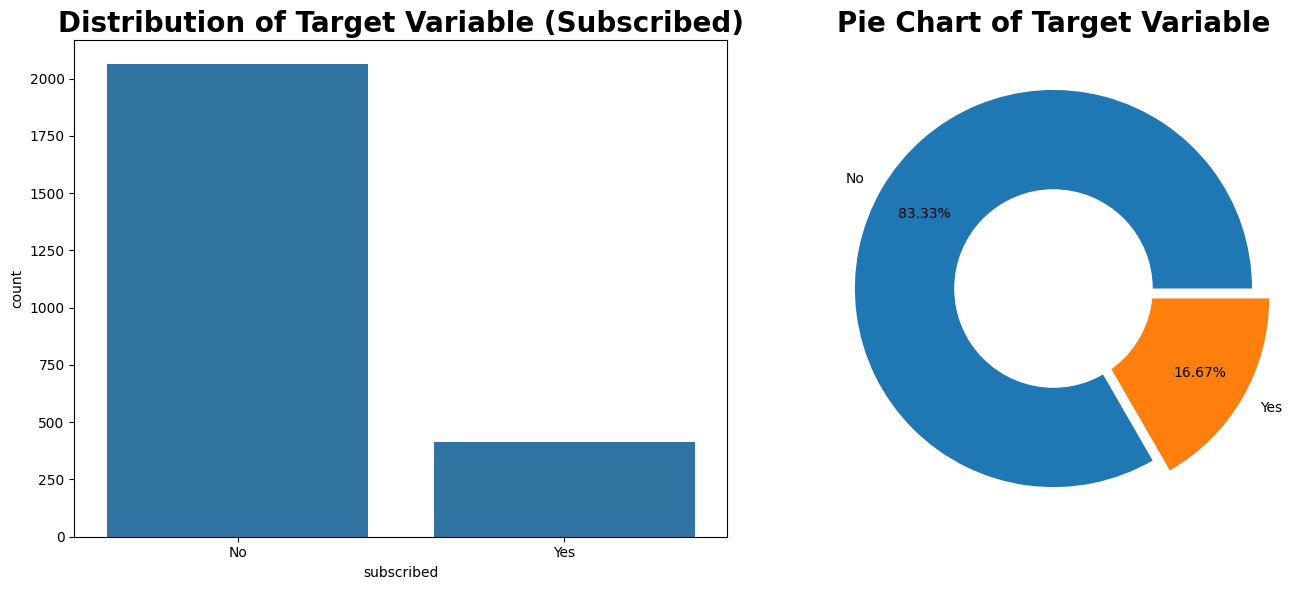

In [325]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(x="Exited", data=train_original, ax=axes[0])
axes[0].set_title('Distribution of Target Variable (Subscribed)', fontweight='bold', size=20)
axes[0].set_xticks(ticks=[0, 1],labels=['No', 'Yes'])
axes[0].set_xlabel("subscribed")

train_original["Exited"].value_counts().plot(kind='pie', ax=axes[1], explode=(0.0, 0.1), autopct="%.2f%%", labels=['No', 'Yes'], pctdistance=0.75)
axes[1].add_artist(plt.Circle((0, 0), 0.5, fc='w'))
axes[1].set_title('Pie Chart of Target Variable', fontweight='bold', size=20)
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [326]:
def numerical_features_plot(df, feature, target):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Analysis of {feature}', fontsize=16, fontweight='bold')

    # Boxplot
    sns.boxplot(data=df, x=feature, y=target, hue=target, orient='h', ax=axes[0])
    axes[0].set_title(f'Boxplot of {feature}')
    axes[0].legend_.remove()  # Turn off legend

    # Violinplot
    sns.violinplot(data=df, x=feature, y=target, hue=target, orient='h', ax=axes[1])
    axes[1].set_title(f'Violinplot of {feature}')
    axes[1].legend_.remove()  # Turn off legend

    # Histogram with KDE
    sns.histplot(data=df, x=feature, hue=target, kde=True, ax=axes[2], alpha=0.6)
    axes[2].set_title(f'Distribution of {feature}')

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

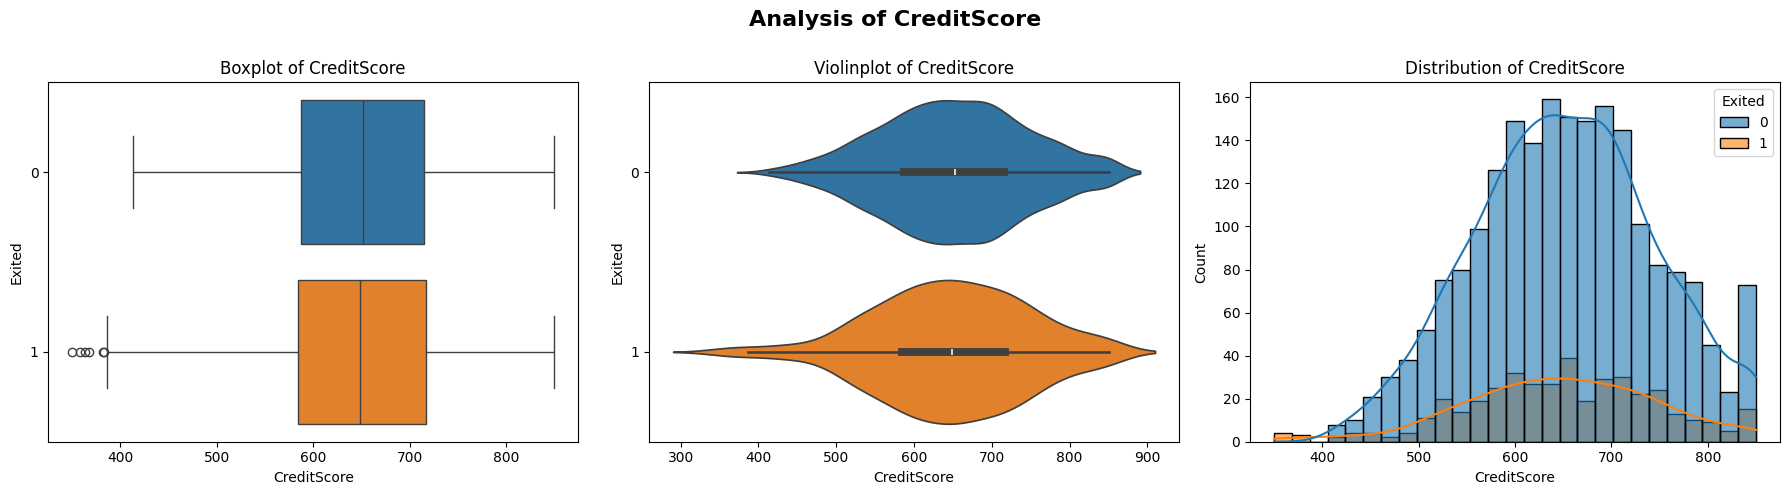

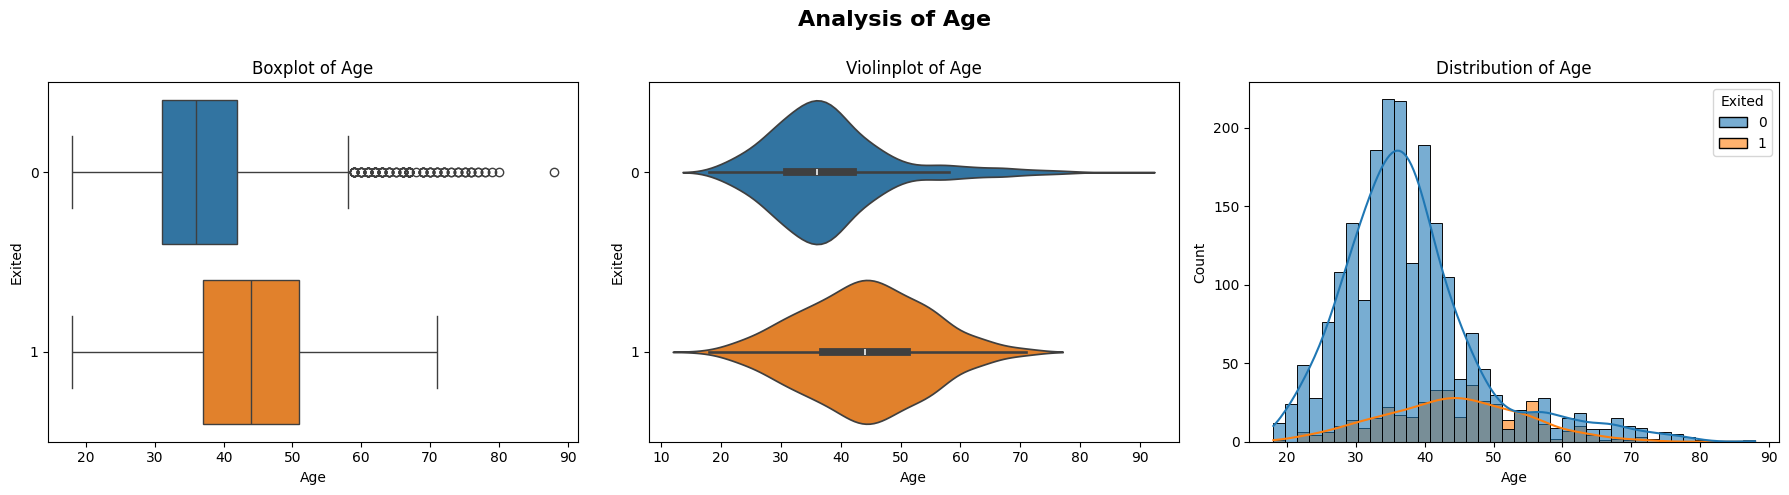

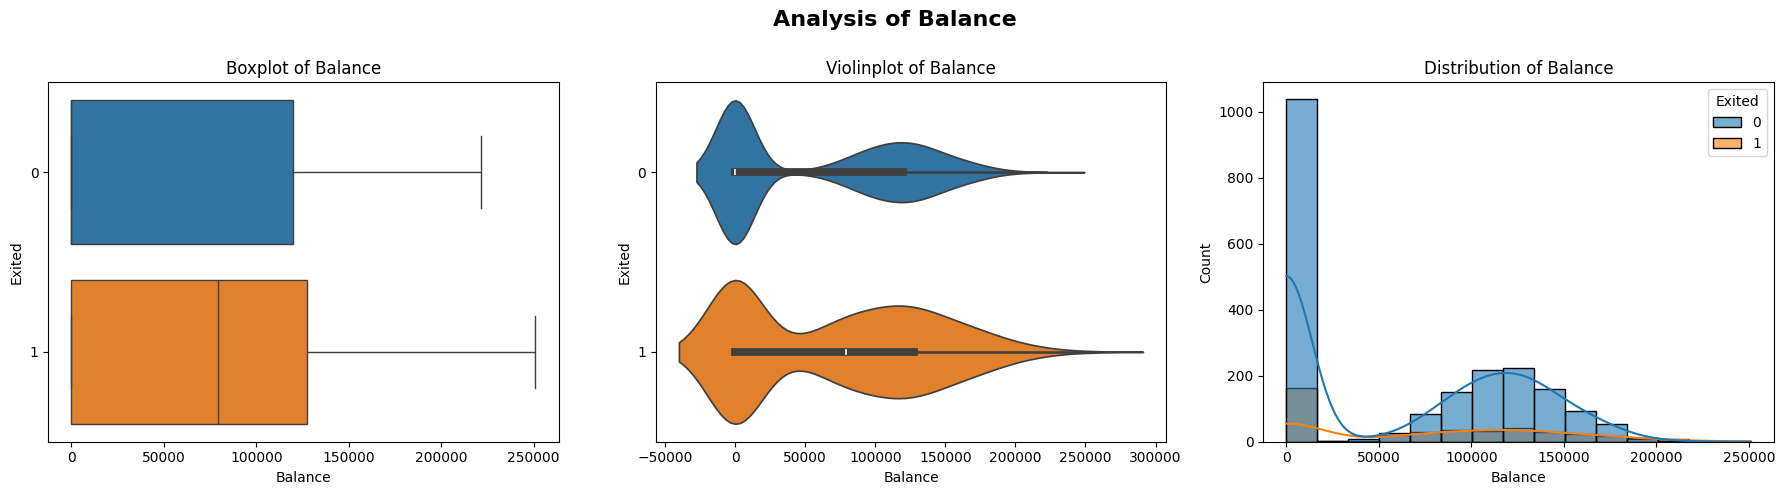

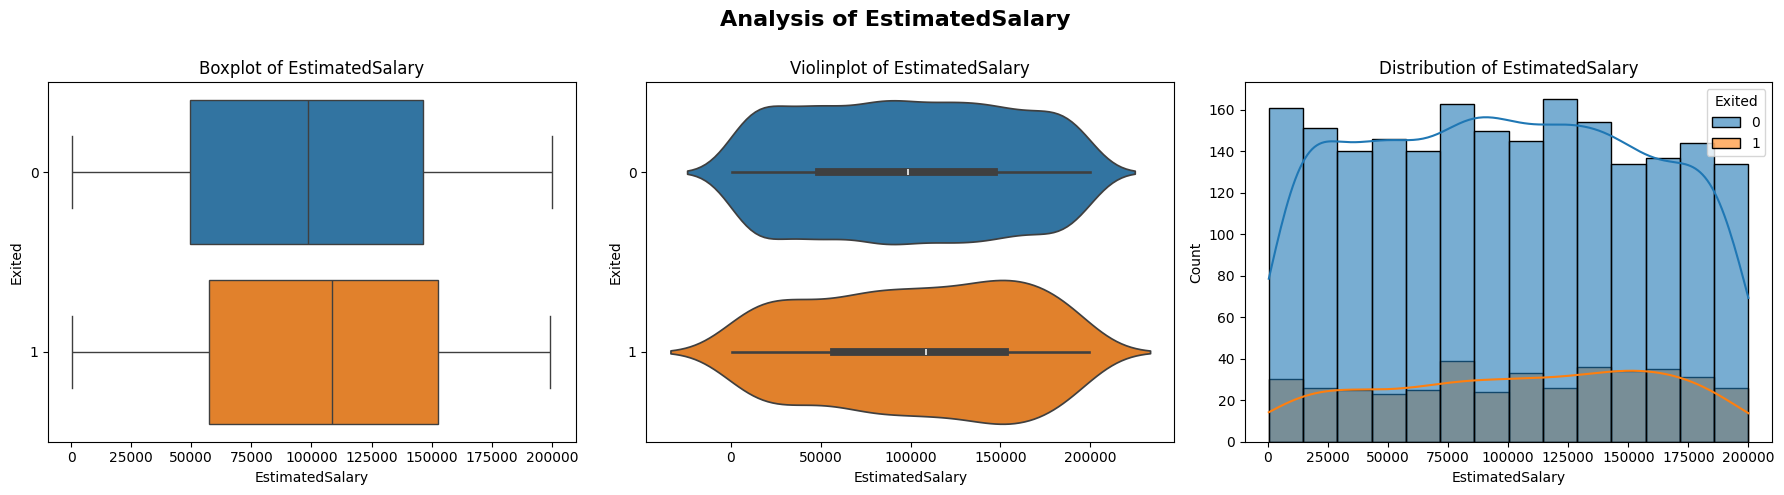

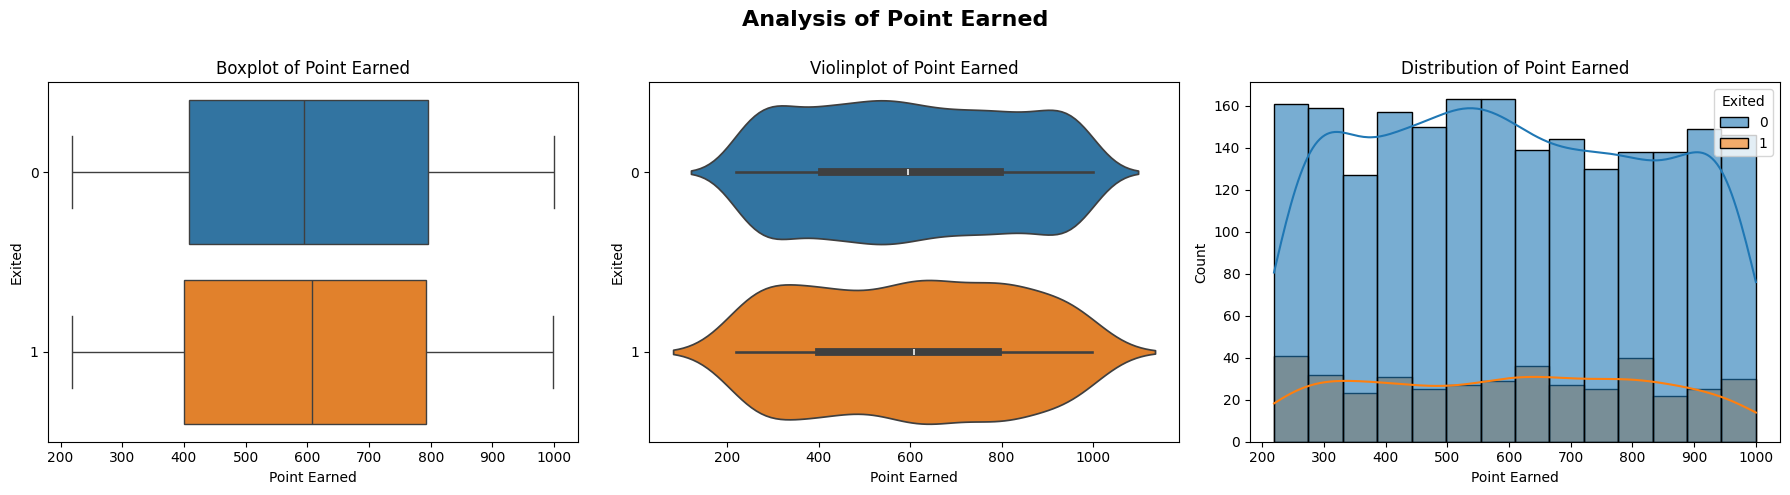

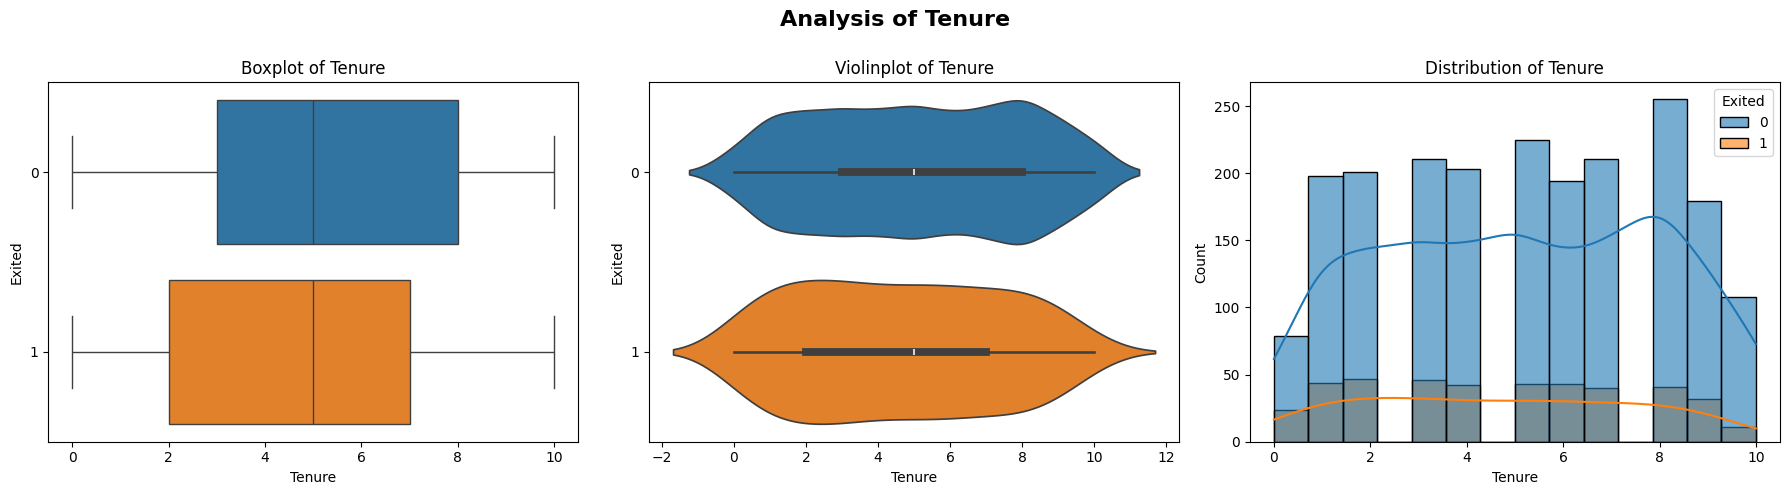

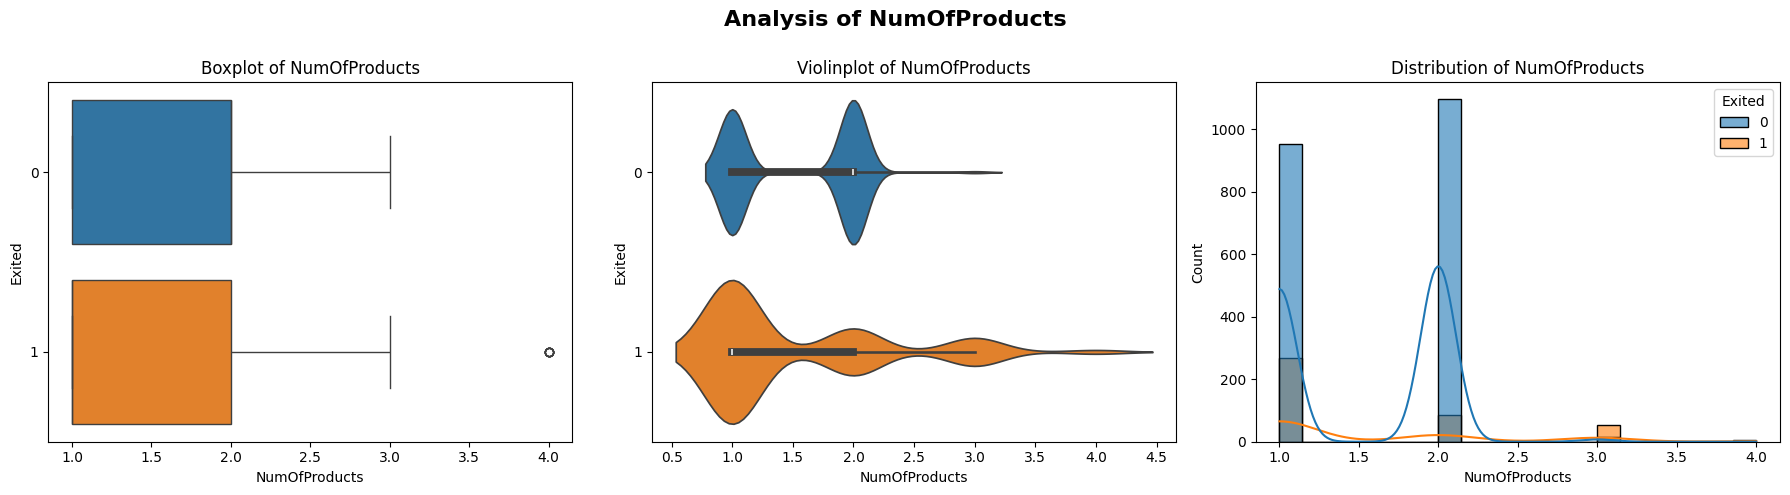

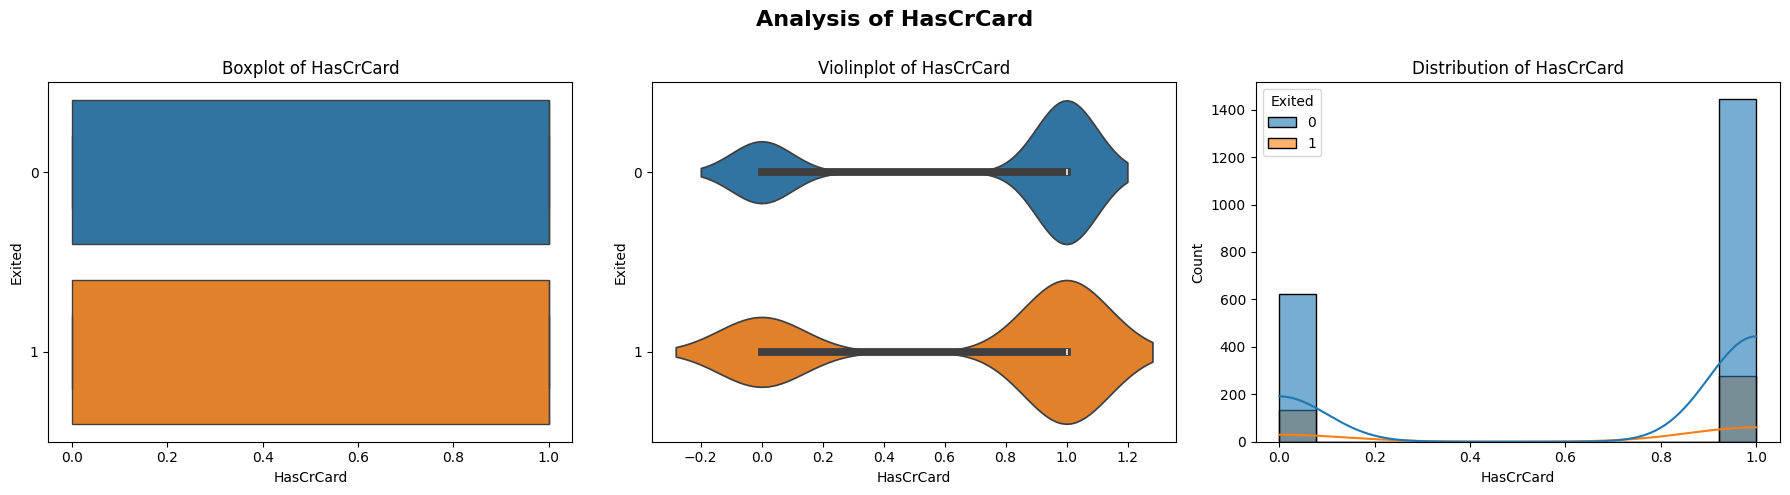

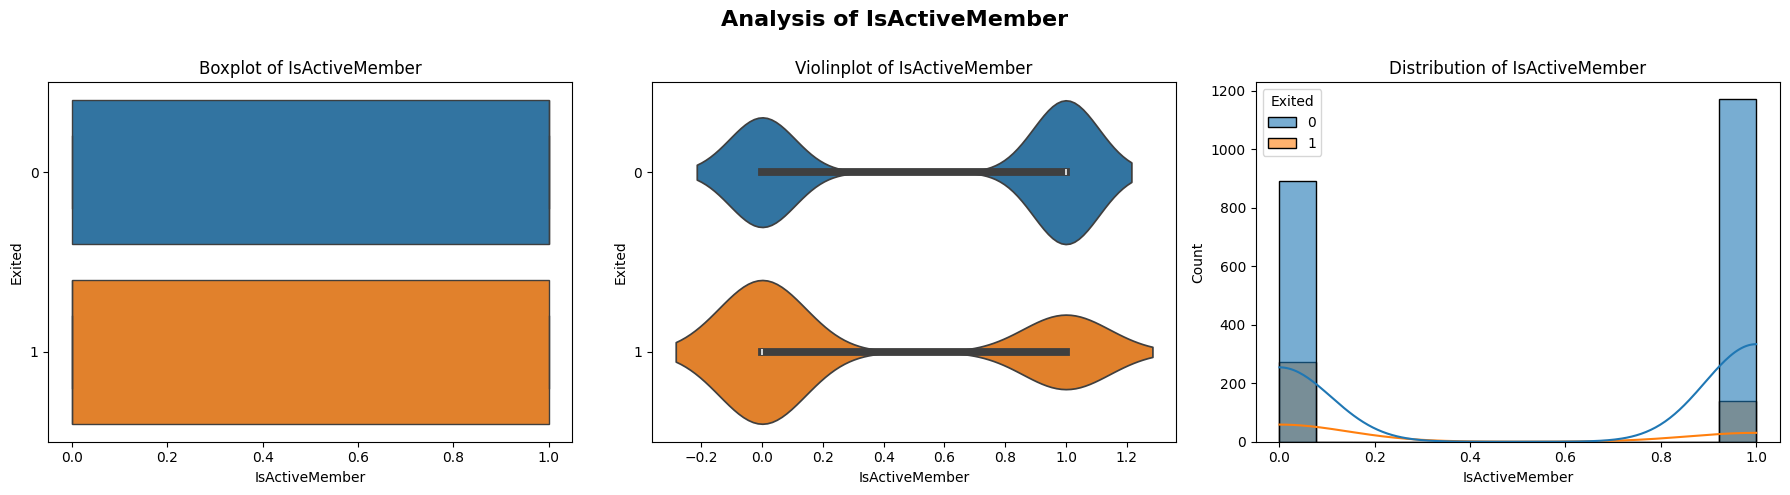

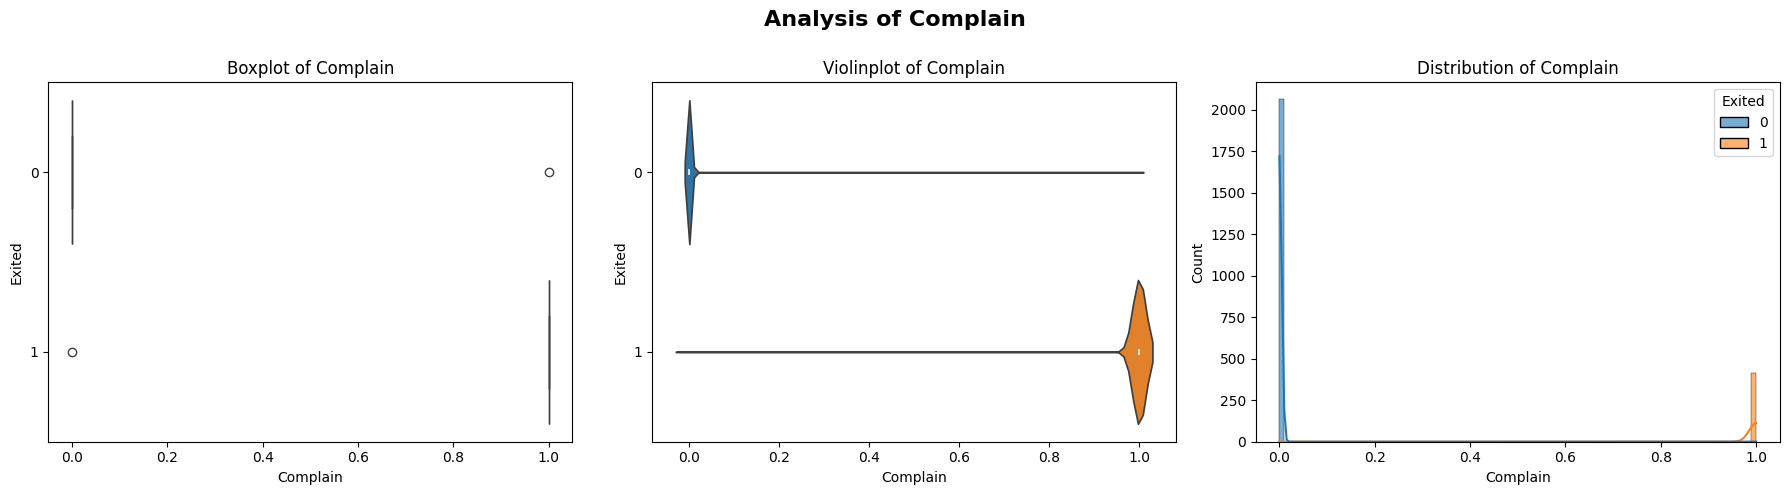

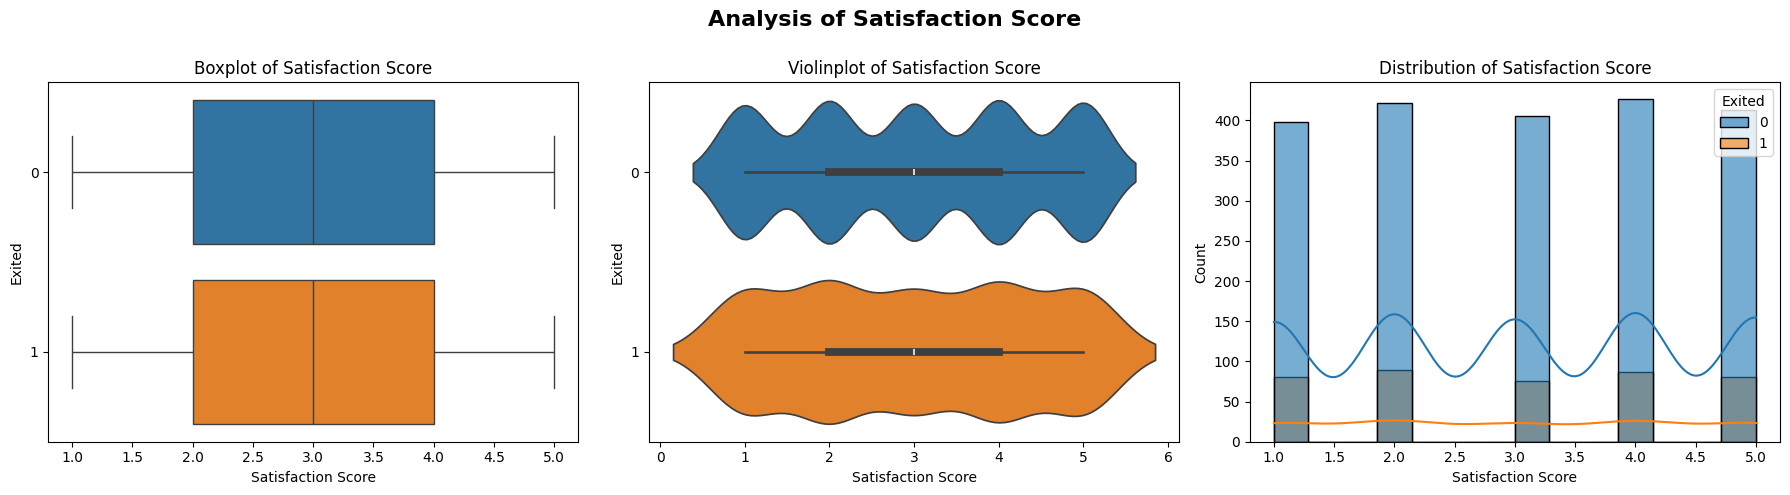

In [327]:
for feature in NUMS_cont+NUMS_dis:
    numerical_features_plot(train, feature, "Exited")

In [328]:
def categorical_features_plot(df, feature):
    value_counts = df[feature].value_counts()
    
    top_n = min(10, len(value_counts))
    top_categories = value_counts.nlargest(top_n)
    
    df_plot = df[df[feature].isin(top_categories.index)]

    top_percentages = (top_categories / len(df)) * 100

    plt.figure(figsize=(25, 6))

    plt.subplot(1, 2, 1)
    sns.countplot(df_plot, x=feature, palette=sns.color_palette('viridis'))
    plt.title(f"Count Plot of{(' Top ' + str(top_n)) if len(value_counts) > 10 else ''} Categories of {feature}", size=16, fontweight='bold')

    plt.subplot(1, 2, 2)
    plt.pie(
        top_percentages,
        labels=top_percentages.index,
        autopct=lambda pct: f"{pct:.2f}%",
        pctdistance=0.75
    )
    plt.gca().add_artist(plt.Circle((0, 0), 0.5, fc='w'))  # Donut hole
    plt.title(
        f"{('Top ' + str(top_n)) if len(value_counts) > 10 else ''} {feature} Categories as % of Full Dataset",
        size=16,
        fontweight='bold'
    )
    plt.ylabel("")

    plt.tight_layout()
    plt.show()

C:\Users\angel\AppData\Local\Temp\ipykernel_41792\1781695723.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df_plot, x=feature, palette=sns.color_palette('viridis'))
C:\Users\angel\AppData\Local\Temp\ipykernel_41792\1781695723.py:14: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.countplot(df_plot, x=feature, palette=sns.color_palette('viridis'))


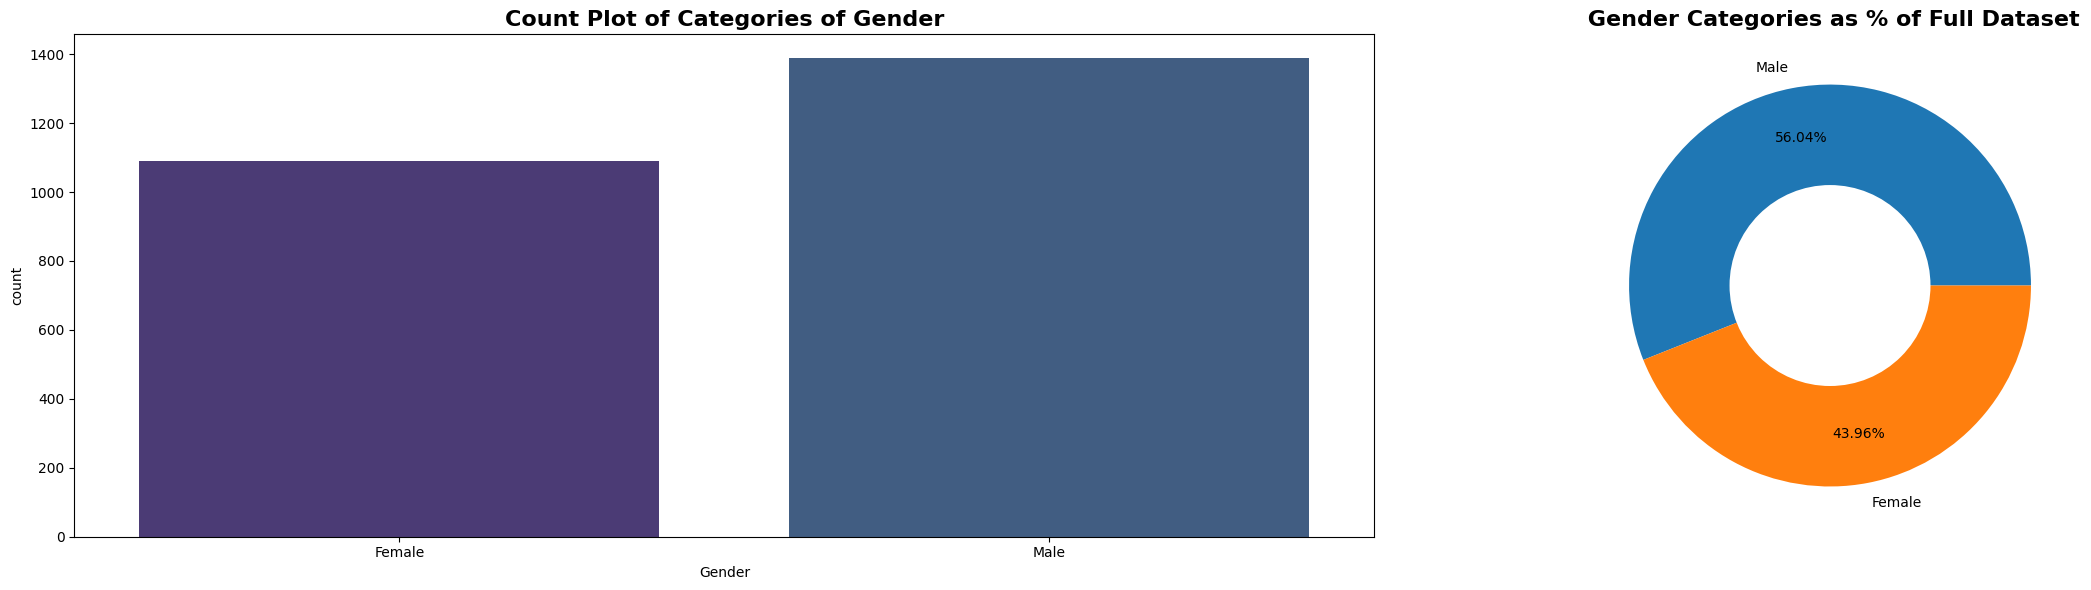

C:\Users\angel\AppData\Local\Temp\ipykernel_41792\1781695723.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df_plot, x=feature, palette=sns.color_palette('viridis'))
C:\Users\angel\AppData\Local\Temp\ipykernel_41792\1781695723.py:14: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.countplot(df_plot, x=feature, palette=sns.color_palette('viridis'))


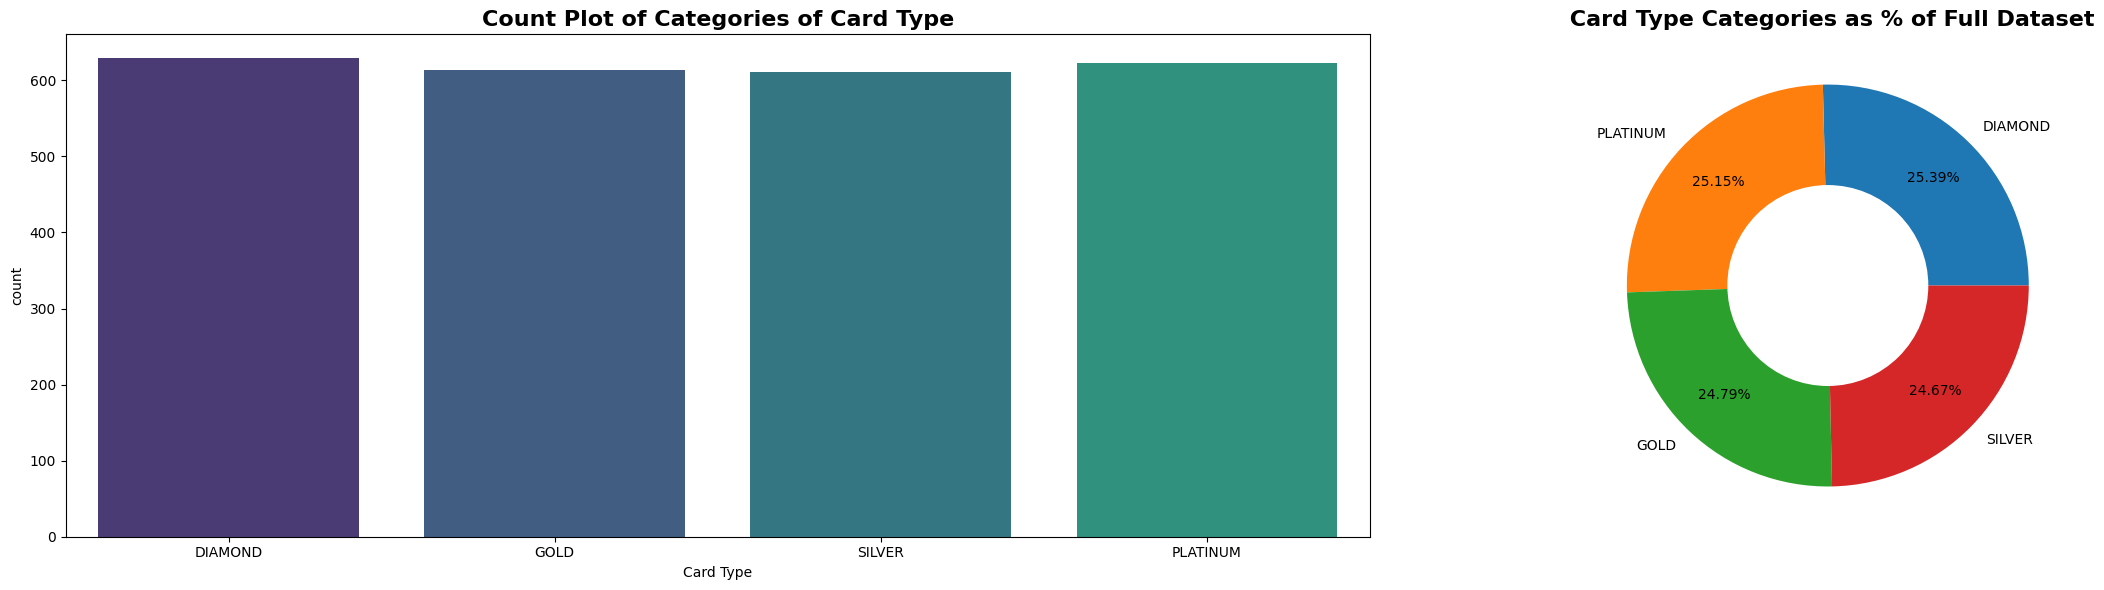

In [329]:
for feature in CAT:
    if feature == 'day':
        continue
    categorical_features_plot(train, feature)

In [330]:
df

,RowNumber,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned,Exited
0,1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,1,3,DIAMOND,456,0
1,2,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425,0
2,3,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,5,DIAMOND,484,1
3,4,497,Spain,Male,24,3,0.00,2,1,0,76390.01,0,3,GOLD,249,0
4,5,635,Spain,Female,35,7,0.00,2,1,1,65951.65,0,2,GOLD,318,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2472,2473,479,Spain,Male,35,4,125920.98,1,1,1,20393.44,0,5,SILVER,555,0
2473,2474,741,Spain,Male,35,6,74371.49,1,0,0,99595.67,0,2,SILVER,295,0
2474,2475,606,Spain,Male,30,8,180307.73,2,1,1,1914.41,0,3,SILVER,567,0
2475,2476,841,Spain,Male,28,4,0.00,2,1,1,179436.60,0,5,GOLD,393,0


c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-package

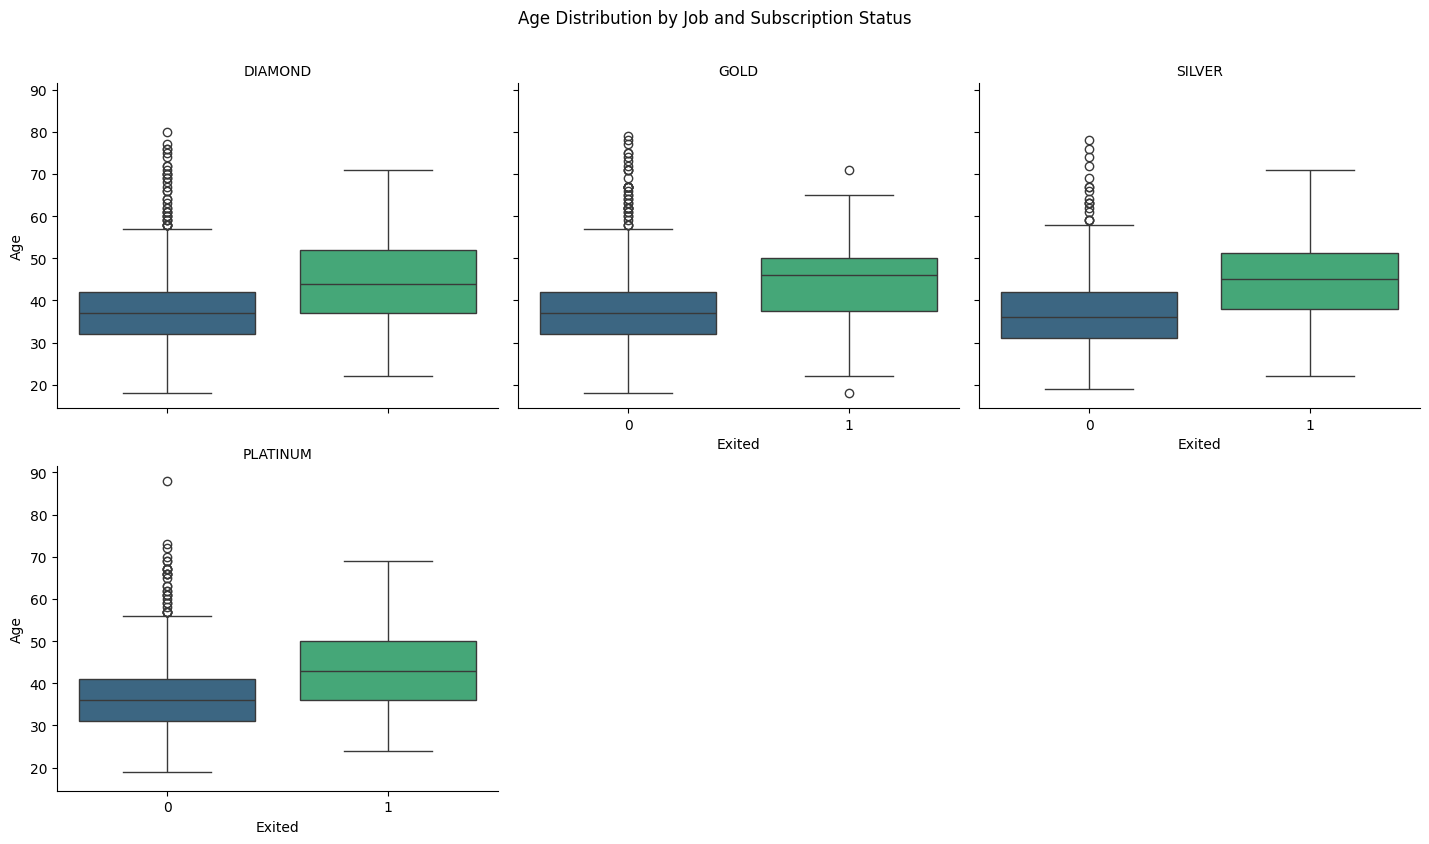

In [331]:
df = train_original.copy()
g = sns.FacetGrid(df[df['Card Type'].isin(df['Card Type'].value_counts().head(6).index)], 
                  col='Card Type', col_wrap=3, height=4, aspect=1.2)
g.map_dataframe(sns.boxplot, x='Exited', y='Age', palette='viridis')
g.set_titles("{col_name}")
g.fig.suptitle('Age Distribution by Job and Subscription Status', y=1.05)
plt.show()

c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-package

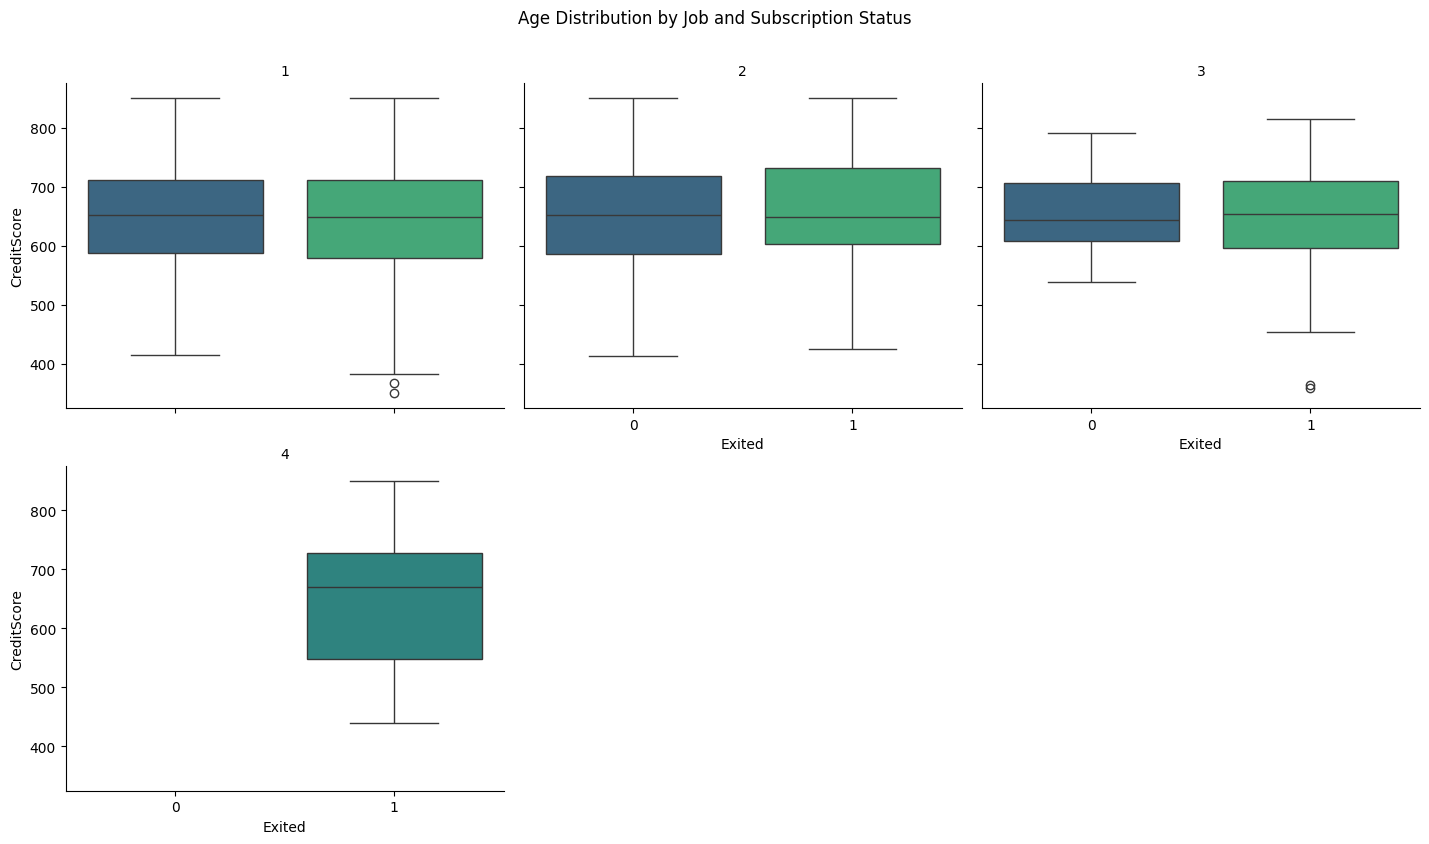

In [452]:
df = train_original.copy()
g = sns.FacetGrid(df[df['NumOfProducts'].isin(df['NumOfProducts'].value_counts().head(6).index)], 
                  col='NumOfProducts', col_wrap=3, height=4, aspect=1.2)
g.map_dataframe(sns.boxplot, x='Exited', y='CreditScore', palette='viridis')
g.set_titles("{col_name}")
g.fig.suptitle('Age Distribution by Job and Subscription Status', y=1.05)
plt.show()

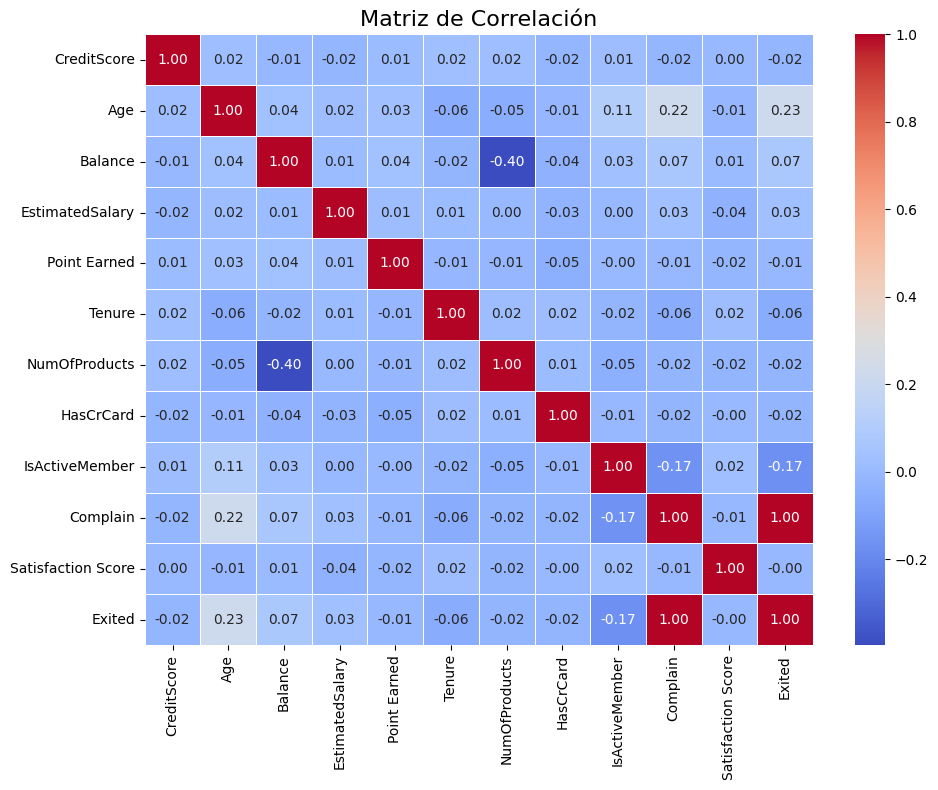

In [333]:

# Calcular la correlación
correlation_matrix = train_original[NUMS_cont+NUMS_dis+["Exited"]].corr()

# Crear el gráfico de correlación
plt.figure(figsize=(10, 8))  # Tamaño de la figura
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)

# Mejorar la visualización
plt.title('Matriz de Correlación', fontsize=16)
plt.tight_layout()

# Mostrar el gráfico
plt.show()


In [334]:


# Función para calcular IV
def calculate_iv(df, feature, target):
    # Paso 1: Agrupar por la variable característica y contar buenos y malos
    df_grouped = df.groupby(feature)[target].agg(['count', 'sum'])
    
    # Paso 2: Calcular buenos y malos
    df_grouped['bad'] = df_grouped['count'] - df_grouped['sum']
    df_grouped['good'] = df_grouped['sum']
    # print(df_grouped['count'])
    
    # Paso 3: Calcular distribución de buenos y malos
    df_grouped['dist_good'] = df_grouped['good'] / df_grouped['good'].sum()
    df_grouped['dist_bad'] = df_grouped['bad'] / df_grouped['bad'].sum()
    
    # Paso 4: Calcular WoE (Weight of Evidence)
    df_grouped['woe'] = np.log(df_grouped['dist_good'] / df_grouped['dist_bad'])
    
    # Paso 5: Calcular el IV (Information Value)
    df_grouped['iv'] = (df_grouped['dist_good'] - df_grouped['dist_bad']) * df_grouped['woe']
    
    # El IV total es la suma de los IV por cada grupo
    iv = df_grouped['iv'].sum()
    
    return iv, df_grouped
def calculate_iv_continuous(df, feature, target, bins=10, epsilon=0.5):
    # Paso 1: Discretizar la variable continua en 'bins' (intervalos)
    df['binned'] = pd.cut(df[feature], bins=bins)
    # print(df['binned'])
    # Paso 2: Contar la cantidad de buenos (1s) y malos (0s) en cada intervalo
    df_grouped = df.groupby('binned')[target].agg(['count', 'sum'])
    df_grouped['bad'] = df_grouped['count'] - df_grouped['sum']
    df_grouped['good'] = df_grouped['sum']
    
    # Paso 3: Calcular las distribuciones de buenos y malos
    df_grouped['dist_good'] = (df_grouped['good']+epsilon) / df_grouped['good'].sum()
    df_grouped['dist_bad'] = (df_grouped['bad']+epsilon) / df_grouped['bad'].sum()

    # Paso 4: Calcular WoE (Weight of Evidence)
    df_grouped['woe'] = np.log(df_grouped['dist_good'] / df_grouped['dist_bad'])
    
    # Paso 5: Calcular el IV (Information Value)
    df_grouped['iv'] = (df_grouped['dist_good'] - df_grouped['dist_bad']) * df_grouped['woe']
    # print(df_grouped)
    # El IV total es la suma de los IV por cada intervalo
    iv = df_grouped['iv'].sum()
    
    return iv, df_grouped




In [335]:
# Calcular IV de la variable 'edad' respecto a 'default'
iv, grouped_df = calculate_iv(train_original[NUMS_dis+NUMS_cont+CAT+['Exited']], 'Complain', 'Exited')
dict_iv = {}
for i in NUMS_dis+CAT:
    iv, grouped_df = calculate_iv(train_original[NUMS_dis+NUMS_cont+CAT+['Exited']], i, 'Exited')
    dict_iv[i] = iv
    
for i in NUMS_cont+['NumOfProducts']:
    iv, grouped_df = calculate_iv_continuous(train_original[NUMS_dis+NUMS_cont+CAT+['Exited']], i, 'Exited')
    dict_iv[i] = iv
pd.DataFrame.from_dict(dict_iv, orient='index', columns=['IV']).sort_values(by='IV', ascending=False)

C:\Users\angel\AppData\Local\Temp\ipykernel_41792\2562871777.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['binned'] = pd.cut(df[feature], bins=bins)
C:\Users\angel\AppData\Local\Temp\ipykernel_41792\2562871777.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby('binned')[target].agg(['count', 'sum'])
C:\Users\angel\AppData\Local\Temp\ipykernel_41792\2562871777.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the c

,IV
Complain,13.613267
NumOfProducts,0.790458
Age,0.620924
IsActiveMember,0.209688
Balance,0.200882
CreditScore,0.092424
Gender,0.083140
Tenure,0.038100
EstimatedSalary,0.028622
Point Earned,0.027610


In [337]:
CATS1 = []
SIZES = {}
for c in  CAT:
    train[c],_ = train[c].factorize()
    train[c] = train[c].astype('int32')

print("New CATS:", CATS1 )
print("Cardinality of all CATS:", SIZES )

New CATS: []
Cardinality of all CATS: {}


In [340]:
train

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned,Exited
0,608,0,41,1,83807.86,1,0,1,112542.58,1,3,0,456,0
1,850,0,43,2,125510.82,1,1,1,79084.10,0,5,1,425,0
2,645,1,44,8,113755.78,2,1,0,149756.71,1,5,0,484,1
3,497,1,24,3,0.00,2,1,0,76390.01,0,3,1,249,0
4,635,0,35,7,0.00,2,1,1,65951.65,0,2,1,318,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2472,479,1,35,4,125920.98,1,1,1,20393.44,0,5,2,555,0
2473,741,1,35,6,74371.49,1,0,0,99595.67,0,2,2,295,0
2474,606,1,30,8,180307.73,2,1,1,1914.41,0,3,2,567,0
2475,841,1,28,4,0.00,2,1,1,179436.60,0,5,1,393,0


c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:59:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%
ROC AUC: 1.00
Confusion Matrix:
[[608   0]
 [  0 136]]


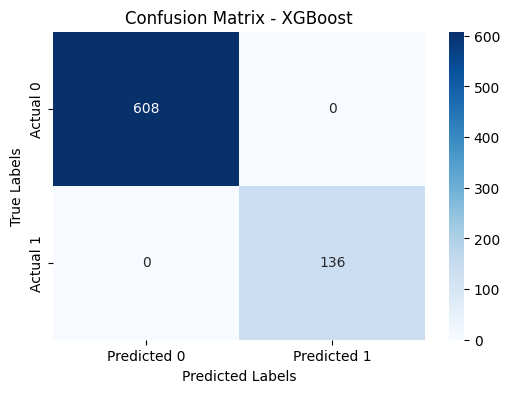

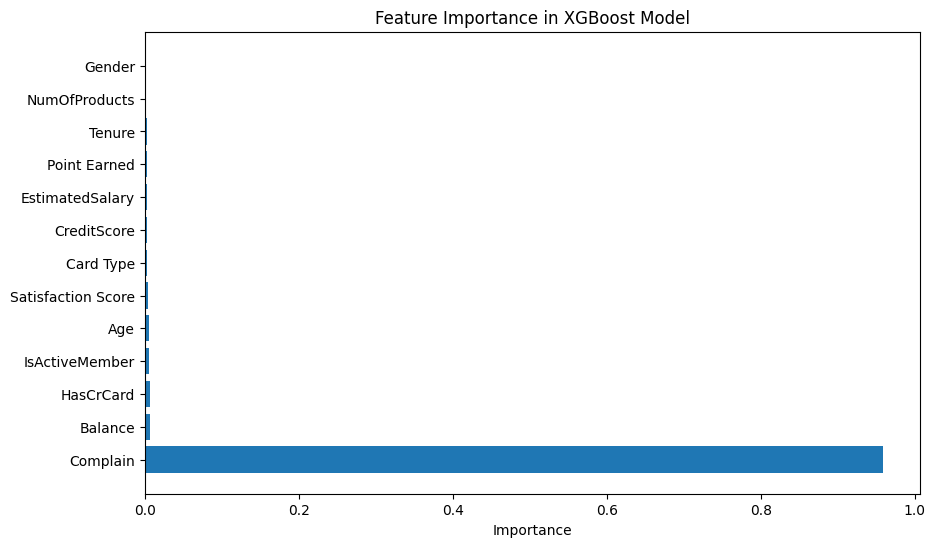

In [371]:
X = train.drop(columns=['Exited'])  # Características
y = train['Exited'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Paso 2: Crear y entrenar el modelo XGBoost
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',  # Para clasificación binaria
    eval_metric='logloss',  # Métrica para evaluar el modelo
    use_label_encoder=False,  # No usar label encoder de XGBoost
    random_state=42
)

# Entrenar el modelo
xgb_model.fit(X_train, y_train)

# Paso 3: Realizar predicciones
y_pred = xgb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Mostrar las métricas
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')
print(f'ROC AUC: {roc_auc:.2f}')

# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualizar la matriz de confusión con un gráfico de calor
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Paso 5: Obtener la importancia de las características
importances = xgb_model.feature_importances_

# Paso 6: Visualizar la importancia de las características
indices = np.argsort(importances)[::-1]  # Ordenar las importancias de mayor a menor

plt.figure(figsize=(10, 6))
plt.title('Feature Importance in XGBoost Model')
plt.barh(range(len(importances)), importances[indices], align='center')
plt.yticks(range(len(importances)), X.columns[indices])
plt.xlabel('Importance')
plt.show()

Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%
ROC AUC: 1.00
Confusion Matrix:
[[608   0]
 [  0 136]]


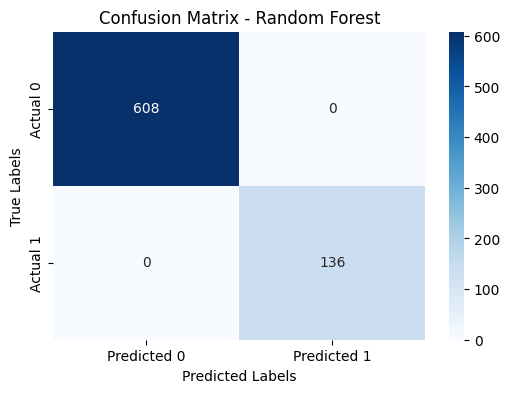

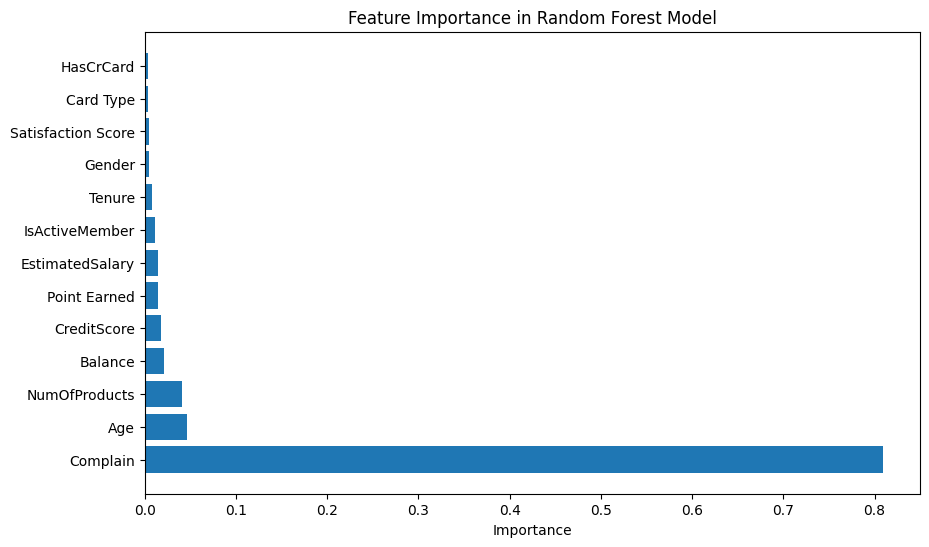

In [372]:

# Paso 1: Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Paso 2: Crear y entrenar el modelo Random Forest
rf_model = RandomForestClassifier(
    n_estimators=50,  # Número de árboles en el bosque
    random_state=42    # Asegurar reproducibilidad
)

# Entrenar el modelo
rf_model.fit(X_train, y_train)

# Paso 3: Realizar predicciones
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Mostrar las métricas
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')
print(f'ROC AUC: {roc_auc:.2f}')

# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualizar la matriz de confusión con un gráfico de calor
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Paso 5: Obtener la importancia de las características
importances = rf_model.feature_importances_

# Paso 6: Visualizar la importancia de las características
indices = np.argsort(importances)[::-1]  # Ordenar las importancias de mayor a menor

plt.figure(figsize=(10, 6))
plt.title('Feature Importance in Random Forest Model')
plt.barh(range(len(importances)), importances[indices], align='center')
plt.yticks(range(len(importances)), X.columns[indices])
plt.xlabel('Importance')
plt.show()

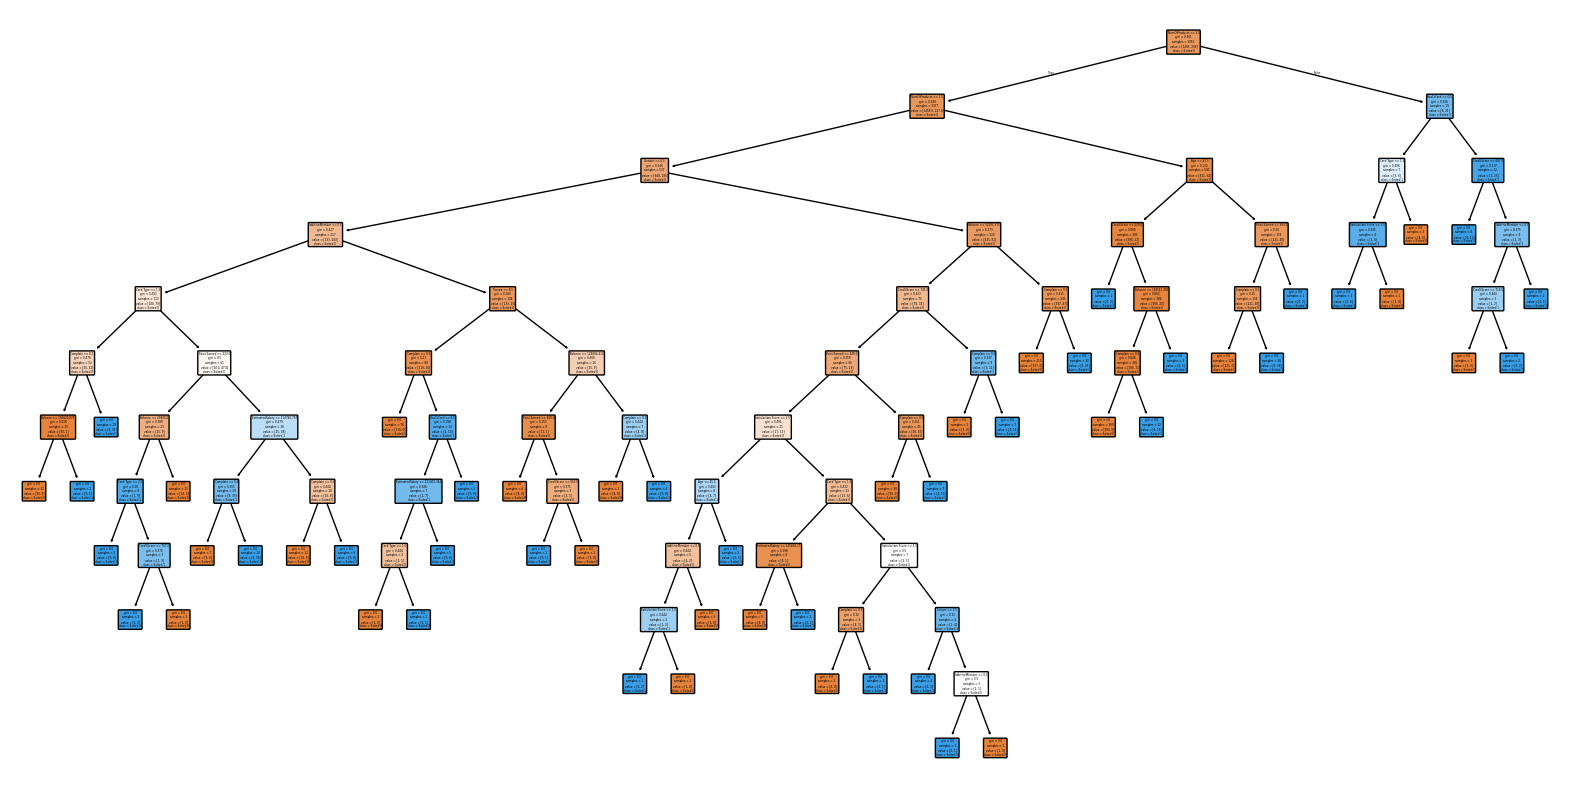

In [346]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Extraer el primer árbol del modelo Random Forest
tree = rf_model.estimators_[0]  # Extrae el primer árbol entrenado

# Visualizar el árbol
plt.figure(figsize=(20,10))  # Ajustar el tamaño de la figura para que el árbol sea visible
plot_tree(tree, filled=True, feature_names=X.columns, class_names=['Exited 0', 'Exited 1'], rounded=True)

# Mostrar el árbol
plt.show()

c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%
ROC AUC: 1.00
Confusion Matrix:
[[608   0]
 [  0 136]]


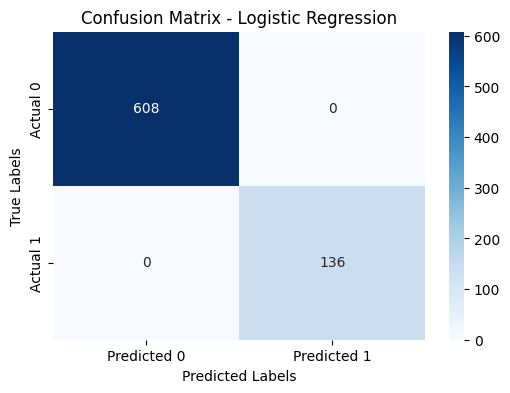


Formula de la regresión logística:
Logit(P(y=1)) = -0.4323 + -0.0054 * CreditScore + -0.6698 * Gender + 0.0531 * Age + -0.0758 * Tenure + 0.0000 * Balance + -0.1941 * NumOfProducts + -0.2213 * HasCrCard + -1.2522 * IsActiveMember + -0.0000 * EstimatedSalary + 8.3798 * Complain + -0.1286 * Satisfaction Score + -0.2712 * Card Type + -0.0009 * Point Earned


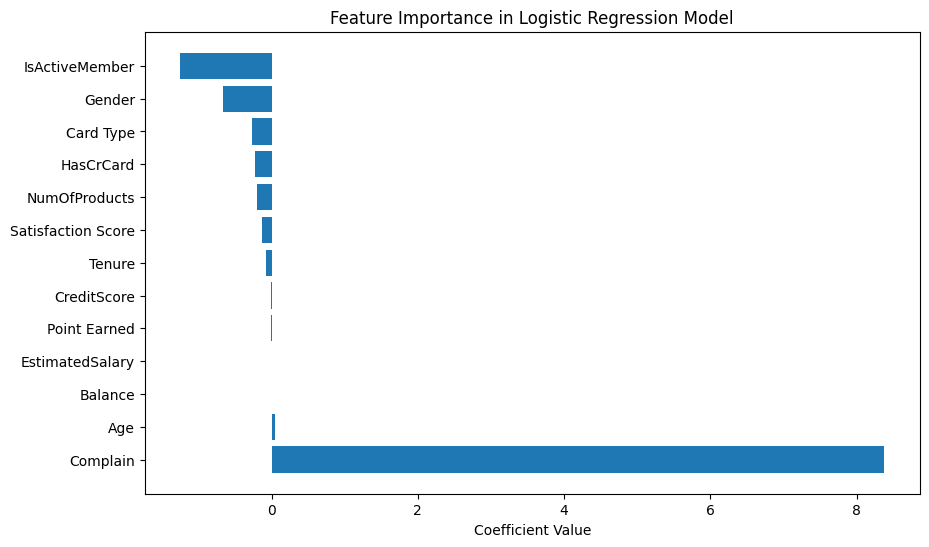

In [373]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Paso 2: Crear y entrenar el modelo de regresión logística
log_reg_model = LogisticRegression(
    random_state=42, 
    max_iter=1000  # Asegurar que la convergencia sea alcanzada
)

# Entrenar el modelo
log_reg_model.fit(X_train, y_train)

# Paso 3: Realizar predicciones
y_pred = log_reg_model.predict(X_test)

# Paso 4: Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Mostrar las métricas
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')
print(f'ROC AUC: {roc_auc:.2f}')

# Generar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar la matriz de confusión
print("Confusion Matrix:")
print(cm)

# Visualizar la matriz de confusión con un gráfico de calor
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Paso 5: Obtener los coeficientes de la regresión logística (importancia de las características)
coefficients = log_reg_model.coef_.flatten()  # Extraemos los coeficientes
intercept = log_reg_model.intercept_  # El intercepto

# Paso 6: Visualizar la importancia de las características
# Crear una tabla con los coeficientes y los nombres de las características
feature_names = X.columns

# Mostrar la fórmula de la regresión logística
formula = f"Logit(P(y=1)) = {intercept[0]:.4f} + " + " + ".join([f"{coefficients[i]:.4f} * {feature_names[i]}" for i in range(len(coefficients))])
print("\nFormula de la regresión logística:")
print(formula)

# Paso 7: Crear un gráfico de barras para mostrar la importancia de las características
indices = np.argsort(coefficients)[::-1]  # Ordenar de mayor a menor

plt.figure(figsize=(10, 6))
plt.title('Feature Importance in Logistic Regression Model')
plt.barh(range(len(coefficients)), coefficients[indices], align='center')
plt.yticks(range(len(coefficients)), feature_names[indices])
plt.xlabel('Coefficient Value')
plt.show()

Existen dos variables categóricas nominales, seis variables numéricas discretas y tres variables numéricas continuas. No hay valores nulos.

In [ ]:
from itertools import combinations

pairs = combinations([i for i in CAT + CATS1 if i != 'Exited'], 2)
new_cols = {}
CATS2 = []

for c1, c2 in pairs:
    name = "_".join(sorted((c1, c2)))
    new_cols[name] = train[c1] * SIZES[c2] + train[c2]
    CATS2.append(name)
if new_cols:
    new_df = pd.DataFrame(new_cols)         
    combine = pd.concat([train, new_df], axis=1) 

print(f"Created {len(CATS2)} new CAT columns")

Created 78 new CAT columns


In [358]:
train

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned,Exited
0,608,0,41,1,83807.86,1,0,1,112542.58,1,3,0,456,0
1,850,0,43,2,125510.82,1,1,1,79084.10,0,5,1,425,0
2,645,1,44,8,113755.78,2,1,0,149756.71,1,5,0,484,1
3,497,1,24,3,0.00,2,1,0,76390.01,0,3,1,249,0
4,635,0,35,7,0.00,2,1,1,65951.65,0,2,1,318,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2472,479,1,35,4,125920.98,1,1,1,20393.44,0,5,2,555,0
2473,741,1,35,6,74371.49,1,0,0,99595.67,0,2,2,295,0
2474,606,1,30,8,180307.73,2,1,1,1914.41,0,3,2,567,0
2475,841,1,28,4,0.00,2,1,1,179436.60,0,5,1,393,0


# sin complain

Fitting 5 folds for each of 729 candidates, totalling 3645 fits


c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:53:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mejores parámetros encontrados:  {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 87.50%
Precision: 77.22%
Recall: 44.85%
F1 Score: 56.74%
ROC AUC: 0.71
Confusion Matrix:
[[590  18]
 [ 75  61]]


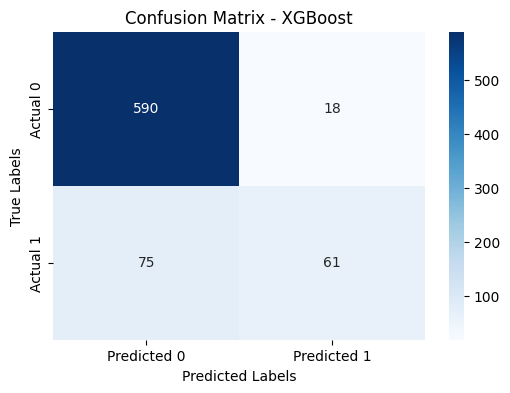

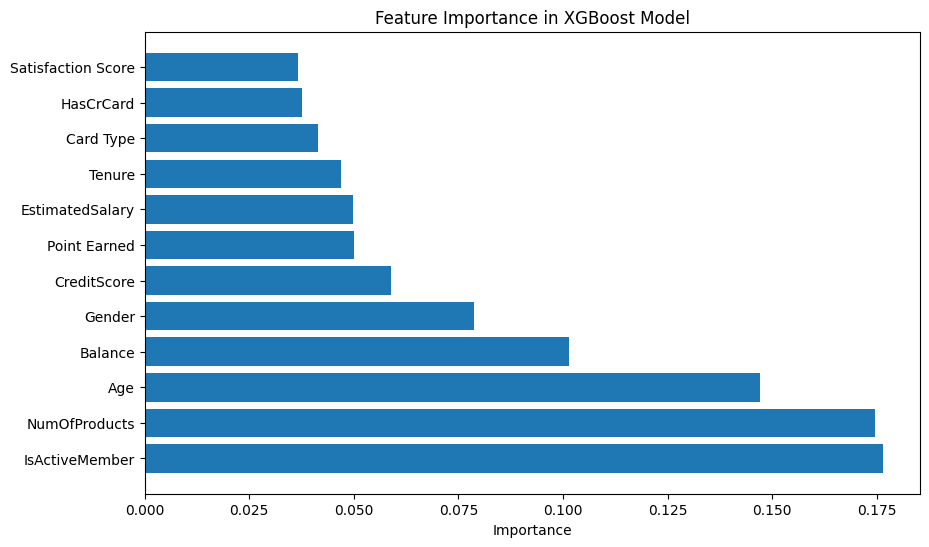

In [388]:
X = train.drop(columns=['Exited',"Complain"])  # Características
y = train['Exited'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


param_grid = {
    'max_depth': [3, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 200],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    # 'gamma': [0, 0.1, 0.2, 0.3],
    'min_child_weight': [1, 4, 7],
    # 'scale_pos_weight': [1, 2, 5],
    # 'reg_alpha': [0, 0.01, 0.1],
    # 'reg_lambda': [0, 0.01, 0.1],
    # 'objective': ['binary:logistic']
}

# Crear el modelo XGBoost
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# Crear el GridSearchCV con el modelo y la búsqueda de parámetros
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, 
                           scoring='accuracy',  # Métrica de evaluación
                           cv=5,  # Validación cruzada con 5 pliegues
                           n_jobs=-1,  # Usar todos los núcleos disponibles
                           verbose=2)  # Mostrar el progreso

# Ajustar el GridSearchCV
grid_search.fit(X_train, y_train)

# Ver los mejores parámetros encontrados
print("Mejores parámetros encontrados: ", grid_search.best_params_)

# Evaluar el modelo con los mejores parámetros
xgb_model = grid_search.best_estimator_

# Paso 3: Realizar predicciones
y_pred = xgb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Mostrar las métricas
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')
print(f'ROC AUC: {roc_auc:.2f}')

# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualizar la matriz de confusión con un gráfico de calor
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Paso 5: Obtener la importancia de las características
importances = xgb_model.feature_importances_

# Paso 6: Visualizar la importancia de las características
indices = np.argsort(importances)[::-1]  # Ordenar las importancias de mayor a menor

plt.figure(figsize=(10, 6))
plt.title('Feature Importance in XGBoost Model')
plt.barh(range(len(importances)), importances[indices], align='center')
plt.yticks(range(len(importances)), X.columns[indices])
plt.xlabel('Importance')
plt.show()

Fitting 5 folds for each of 729 candidates, totalling 3645 fits


c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:47:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mejores parámetros encontrados:  {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 87.70%
Precision: 77.59%
Recall: 48.39%
F1 Score: 59.60%
ROC AUC: 0.73
Confusion Matrix:
[[390  13]
 [ 48  45]]


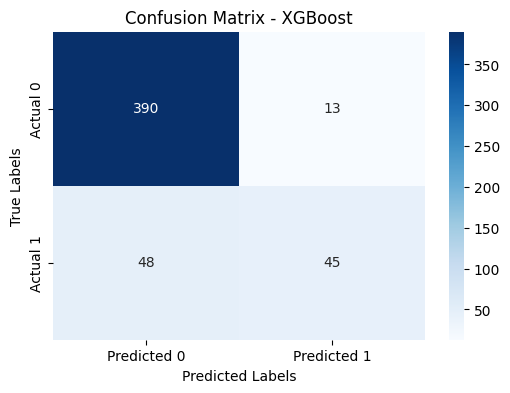

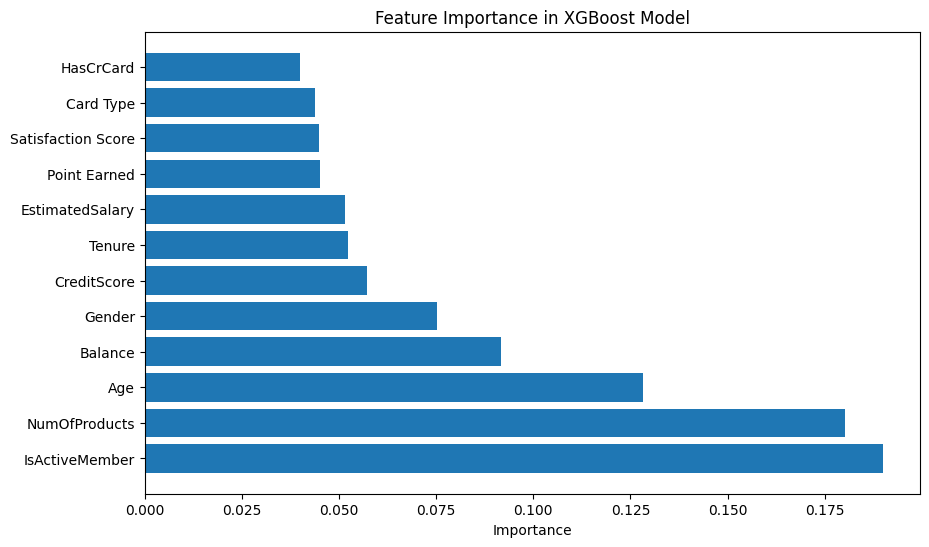

In [426]:
X = train.drop(columns=['Exited',"Complain"])  # Características
y = train['Exited'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



param_grid = {
    'max_depth': [3, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 200],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    # 'gamma': [0, 0.1, 0.2, 0.3],
    'min_child_weight': [1, 4, 7],
    # 'scale_pos_weight': [1, 2, 5],
    # 'reg_alpha': [0, 0.01, 0.1],
    # 'reg_lambda': [0, 0.01, 0.1],
    # 'objective': ['binary:logistic']
}

# Crear el modelo XGBoost
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# Crear el GridSearchCV con el modelo y la búsqueda de parámetros
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, 
                           scoring='recall',  # Métrica de evaluación
                           cv=5,  # Validación cruzada con 5 pliegues
                           n_jobs=-1,  # Usar todos los núcleos disponibles
                           verbose=1)  # Mostrar el progreso

# Ajustar el GridSearchCV
grid_search.fit(X_train, y_train)

# Ver los mejores parámetros encontrados
print("Mejores parámetros encontrados: ", grid_search.best_params_)

# Evaluar el modelo con los mejores parámetros
xgb_model = grid_search.best_estimator_

# Paso 3: Realizar predicciones
y_pred = xgb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Mostrar las métricas
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')
print(f'ROC AUC: {roc_auc:.2f}')

# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualizar la matriz de confusión con un gráfico de calor
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Paso 5: Obtener la importancia de las características
importances = xgb_model.feature_importances_

# Paso 6: Visualizar la importancia de las características
indices = np.argsort(importances)[::-1]  # Ordenar las importancias de mayor a menor

plt.figure(figsize=(10, 6))
plt.title('Feature Importance in XGBoost Model')
plt.barh(range(len(importances)), importances[indices], align='center')
plt.yticks(range(len(importances)), X.columns[indices])
plt.xlabel('Importance')
plt.show()

Fitting 5 folds for each of 648 candidates, totalling 3240 fits


c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1080 fits failed out of a total of 3240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
346 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\ang

Mejores parámetros encontrados:  {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy: 87.50%
Precision: 75.90%
Recall: 46.32%
F1 Score: 57.53%
ROC AUC: 0.72
Confusion Matrix:
[[588  20]
 [ 73  63]]


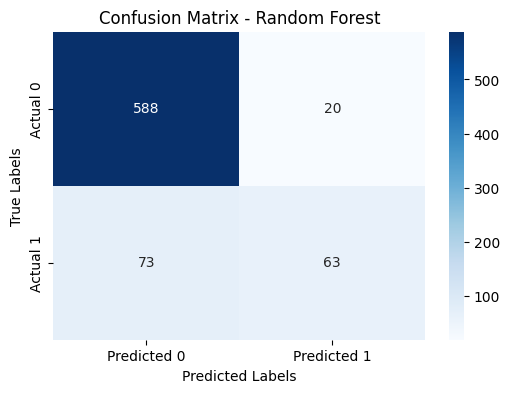

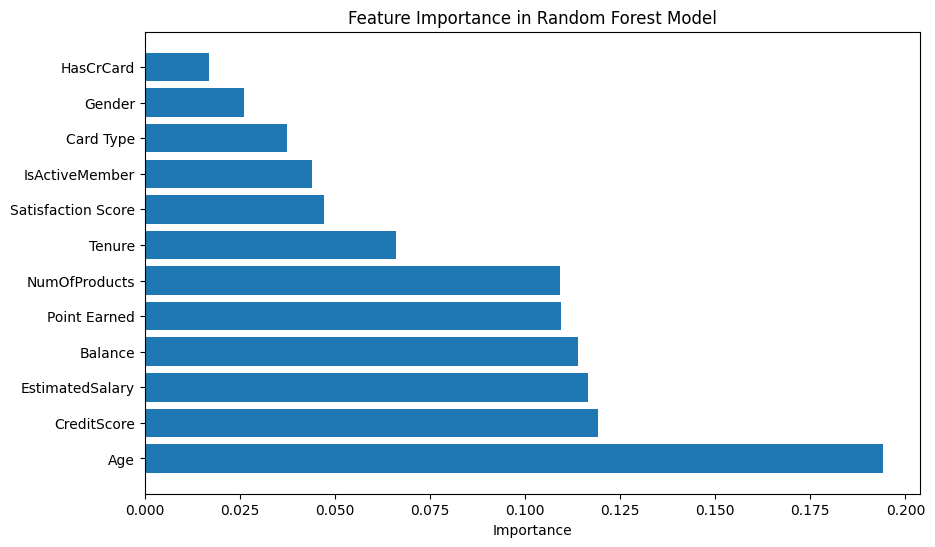

In [ ]:

# Paso 1: Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Paso 2: Crear el modelo Random Forest
rf_model = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],  # Número de árboles en el bosque
    'max_depth': [ 10, 20, 30],  # Profundidad máxima de los árboles
    'min_samples_split': [2, 5, 10],  # Mínimo número de muestras requeridas para dividir un nodo
    'min_samples_leaf': [1, 2, 4, 5],    # Mínimo número de muestras requeridas en una hoja
    'bootstrap': [True],               # Si se deben usar muestras bootstrap para entrenar los árboles
    'max_features': ['auto', 'sqrt', 'log2'], # Número de características a considerar para la división
    'criterion': ['gini', 'entropy'],        # Criterio para medir la calidad de la división (Gini o Entropía)
    'class_weight': [ 'balanced'],       # Ajuste de pesos para clases desbalanceadas
}
# Paso 4: Configurar GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, 
                           scoring='accuracy', cv=5, n_jobs=-1, verbose=2)

# Paso 5: Ajustar el modelo utilizando GridSearchCV
grid_search.fit(X_train, y_train)

# Paso 6: Ver los mejores parámetros encontrados
print("Mejores parámetros encontrados: ", grid_search.best_params_)

# Paso 7: Obtener el mejor modelo
rf_model = grid_search.best_estimator_

# Entrenar el modelo
rf_model.fit(X_train, y_train)

# Paso 3: Realizar predicciones
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Mostrar las métricas
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')
print(f'ROC AUC: {roc_auc:.2f}')

# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualizar la matriz de confusión con un gráfico de calor
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Paso 5: Obtener la importancia de las características
importances = rf_model.feature_importances_

# Paso 6: Visualizar la importancia de las características
indices = np.argsort(importances)[::-1]  # Ordenar las importancias de mayor a menor

plt.figure(figsize=(10, 6))
plt.title('Feature Importance in Random Forest Model')
plt.barh(range(len(importances)), importances[indices], align='center')
plt.yticks(range(len(importances)), X.columns[indices])
plt.xlabel('Importance')
plt.show()

Fitting 5 folds for each of 648 candidates, totalling 3240 fits


c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1080 fits failed out of a total of 3240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
517 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\ang

Mejores parámetros encontrados:  {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 50}
Accuracy: 85.48%
Precision: 61.80%
Recall: 59.14%
F1 Score: 60.44%
ROC AUC: 0.75
Confusion Matrix:
[[369  34]
 [ 38  55]]


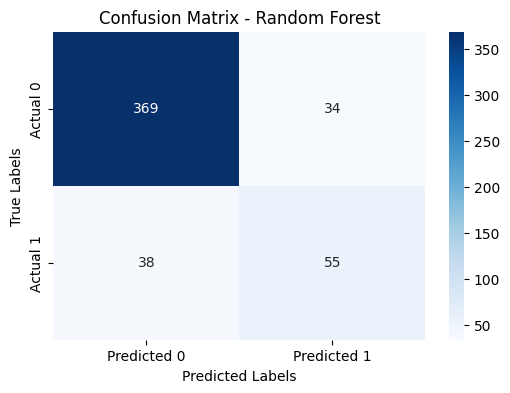

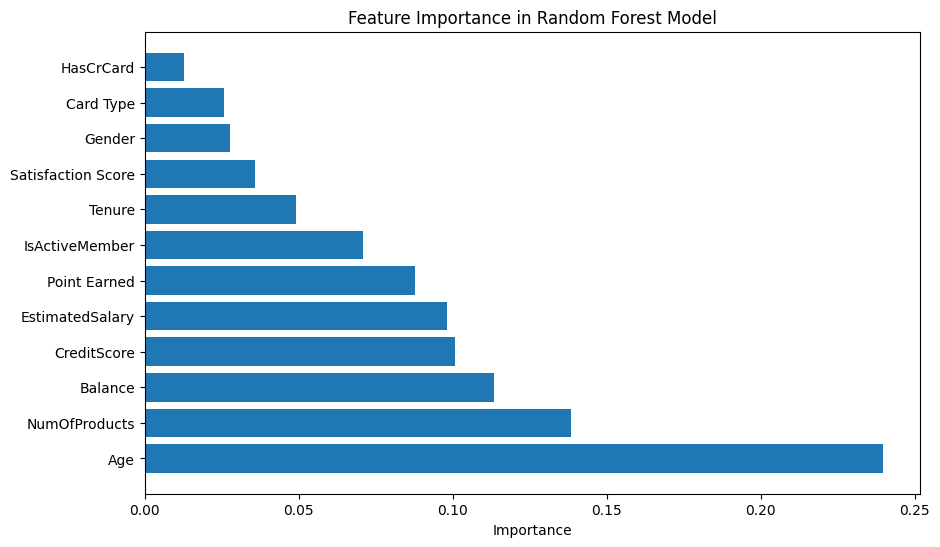

In [425]:
# Paso 1: Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Paso 2: Crear el modelo Random Forest
rf_model = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],  # Número de árboles en el bosque
    'max_depth': [ 10, 20, 30],  # Profundidad máxima de los árboles
    'min_samples_split': [2, 5, 10],  # Mínimo número de muestras requeridas para dividir un nodo
    'min_samples_leaf': [1, 2, 4, 5],    # Mínimo número de muestras requeridas en una hoja
    'bootstrap': [True],               # Si se deben usar muestras bootstrap para entrenar los árboles
    'max_features': ['auto', 'sqrt', 'log2'], # Número de características a considerar para la división
    'criterion': ['gini', 'entropy'],        # Criterio para medir la calidad de la división (Gini o Entropía)
    'class_weight': [ 'balanced'],       # Ajuste de pesos para clases desbalanceadas
}
# Paso 4: Configurar GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, 
                           scoring='recall', cv=5, n_jobs=-1, verbose=2)

# Paso 5: Ajustar el modelo utilizando GridSearchCV
grid_search.fit(X_train, y_train)

# Paso 6: Ver los mejores parámetros encontrados
print("Mejores parámetros encontrados: ", grid_search.best_params_)

# Paso 7: Obtener el mejor modelo
rf_model = grid_search.best_estimator_

# Entrenar el modelo
rf_model.fit(X_train, y_train)

# Paso 3: Realizar predicciones
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Mostrar las métricas
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')
print(f'ROC AUC: {roc_auc:.2f}')

# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualizar la matriz de confusión con un gráfico de calor
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Paso 5: Obtener la importancia de las características
importances = rf_model.feature_importances_

# Paso 6: Visualizar la importancia de las características
indices = np.argsort(importances)[::-1]  # Ordenar las importancias de mayor a menor

plt.figure(figsize=(10, 6))
plt.title('Feature Importance in Random Forest Model')
plt.barh(range(len(importances)), importances[indices], align='center')
plt.yticks(range(len(importances)), X.columns[indices])
plt.xlabel('Importance')
plt.show()

c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 81.72%
Confusion Matrix:
[[604   4]
 [132   4]]


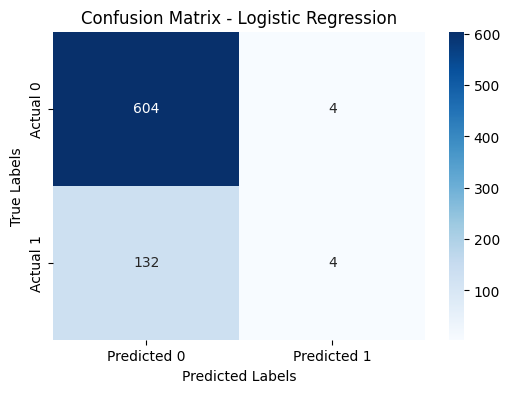


Formula de la regresión logística:
Logit(P(y=1)) = -0.1675 + -0.0028 * CreditScore + -0.6921 * Gender + 0.0513 * Age + -0.0669 * Tenure + 0.0000 * Balance + -0.2072 * NumOfProducts + -0.2441 * HasCrCard + -1.1134 * IsActiveMember + 0.0000 * EstimatedSalary + -0.0098 * Satisfaction Score + 0.0760 * Card Type + -0.0006 * Point Earned


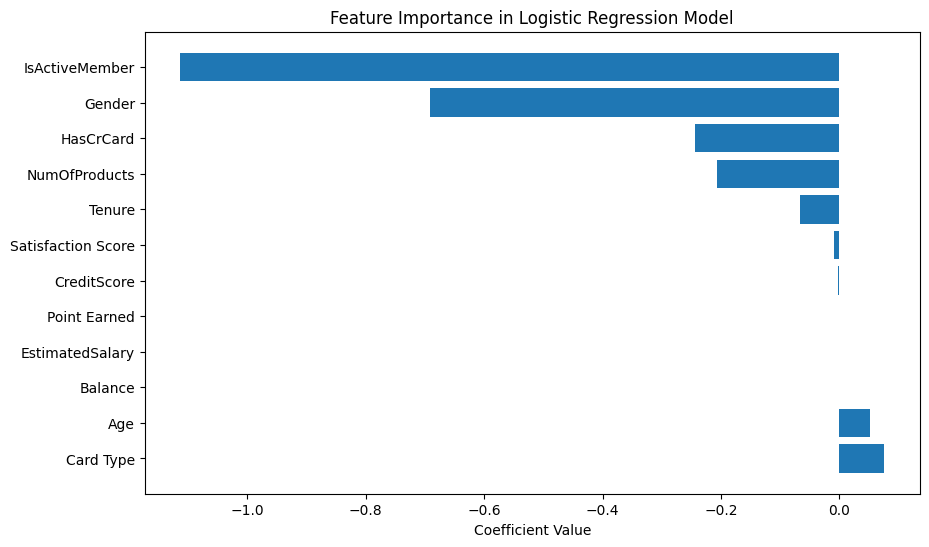

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Paso 2: Crear y entrenar el modelo de regresión logística
log_reg_model = LogisticRegression(
    random_state=42, 
    max_iter=1000  # Asegurar que la convergencia sea alcanzada
)

# Entrenar el modelo
log_reg_model.fit(X_train, y_train)

# Paso 3: Realizar predicciones
y_pred = log_reg_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Mostrar las métricas
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')
print(f'ROC AUC: {roc_auc:.2f}')

# Generar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar la matriz de confusión
print("Confusion Matrix:")
print(cm)

# Visualizar la matriz de confusión con un gráfico de calor
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Paso 5: Obtener los coeficientes de la regresión logística (importancia de las características)
coefficients = log_reg_model.coef_.flatten()  # Extraemos los coeficientes
intercept = log_reg_model.intercept_  # El intercepto

# Paso 6: Visualizar la importancia de las características
# Crear una tabla con los coeficientes y los nombres de las características
feature_names = X.columns

# Mostrar la fórmula de la regresión logística
formula = f"Logit(P(y=1)) = {intercept[0]:.4f} + " + " + ".join([f"{coefficients[i]:.4f} * {feature_names[i]}" for i in range(len(coefficients))])
print("\nFormula de la regresión logística:")
print(formula)

# Paso 7: Crear un gráfico de barras para mostrar la importancia de las características
indices = np.argsort(coefficients)[::-1]  # Ordenar de mayor a menor

plt.figure(figsize=(10, 6))
plt.title('Feature Importance in Logistic Regression Model')
plt.barh(range(len(coefficients)), coefficients[indices], align='center')
plt.yticks(range(len(coefficients)), feature_names[indices])
plt.xlabel('Coefficient Value')
plt.show()

# Opcion 3

In [403]:
train_feture = train.drop(columns=['Exited'])
train_feture

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned
0,608,0,41,1,83807.86,1,0,1,112542.58,1,3,0,456
1,850,0,43,2,125510.82,1,1,1,79084.10,0,5,1,425
2,645,1,44,8,113755.78,2,1,0,149756.71,1,5,0,484
3,497,1,24,3,0.00,2,1,0,76390.01,0,3,1,249
4,635,0,35,7,0.00,2,1,1,65951.65,0,2,1,318
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2472,479,1,35,4,125920.98,1,1,1,20393.44,0,5,2,555
2473,741,1,35,6,74371.49,1,0,0,99595.67,0,2,2,295
2474,606,1,30,8,180307.73,2,1,1,1914.41,0,3,2,567
2475,841,1,28,4,0.00,2,1,1,179436.60,0,5,1,393


In [405]:
train_feture['Balance_zero'] = np.where(train_feture['Balance'] == 1, 1, 0)
train_feture

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned,Balance_zero
0,608,0,41,1,83807.86,1,0,1,112542.58,1,3,0,456,0
1,850,0,43,2,125510.82,1,1,1,79084.10,0,5,1,425,0
2,645,1,44,8,113755.78,2,1,0,149756.71,1,5,0,484,0
3,497,1,24,3,0.00,2,1,0,76390.01,0,3,1,249,0
4,635,0,35,7,0.00,2,1,1,65951.65,0,2,1,318,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2472,479,1,35,4,125920.98,1,1,1,20393.44,0,5,2,555,0
2473,741,1,35,6,74371.49,1,0,0,99595.67,0,2,2,295,0
2474,606,1,30,8,180307.73,2,1,1,1914.41,0,3,2,567,0
2475,841,1,28,4,0.00,2,1,1,179436.60,0,5,1,393,0


In [446]:
train_feture = train.drop(columns=['Exited',"Complain"])
train_feture['Balance_zero'] = np.where(train_feture['Balance'] == 1, 1, 0)

extra=[]
extra_aux=[]
for i in train_feture.columns:
    train_feture[i+"2"] = train_feture[i]
    extra.append(i+"2")
extra_aux=extra.copy()
no_app=[]
for i in [x for x in train_feture.columns if x not in extra]:
    for j in extra:
        if i != j:
            train_feture[i+"*"+j] = train_feture[i]*train_feture[j]
            no_app.append(i+"*"+j)
    extra.remove(i+"2")
train_feture=train_feture.drop(columns=extra_aux)
# for i in train_feture.columns:
#     train_feture[i+"**2"] = train_feture[i]**2
d= [x for x in train_feture.columns if x not in no_app]
for i in d:
    train_feture[i+"**3"] = train_feture[i]**3
for i in d:
    train_feture[i+"reg"] = (train_feture[i]-train_feture[i].mean())/train_feture[i].std()
for i in d:
    train_feture[i+"scaler"] = MinMaxScaler().fit_transform(train_feture[[i]])


C:\Users\angel\AppData\Local\Temp\ipykernel_41792\3592797394.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_feture[i+"*"+j] = train_feture[i]*train_feture[j]
C:\Users\angel\AppData\Local\Temp\ipykernel_41792\3592797394.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_feture[i+"*"+j] = train_feture[i]*train_feture[j]
C:\Users\angel\AppData\Local\Temp\ipykernel_41792\3592797394.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which ha

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1080 fits failed out of a total of 2160.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
373 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\ang

Mejores parámetros encontrados:  {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy: 87.70%
Precision: 68.60%
Recall: 63.44%
F1 Score: 65.92%
ROC AUC: 0.78
Confusion Matrix:
[[376  27]
 [ 34  59]]


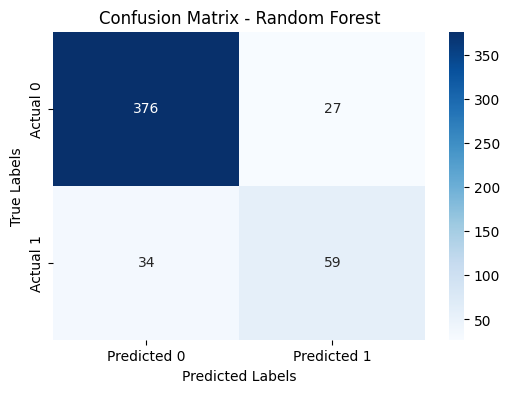

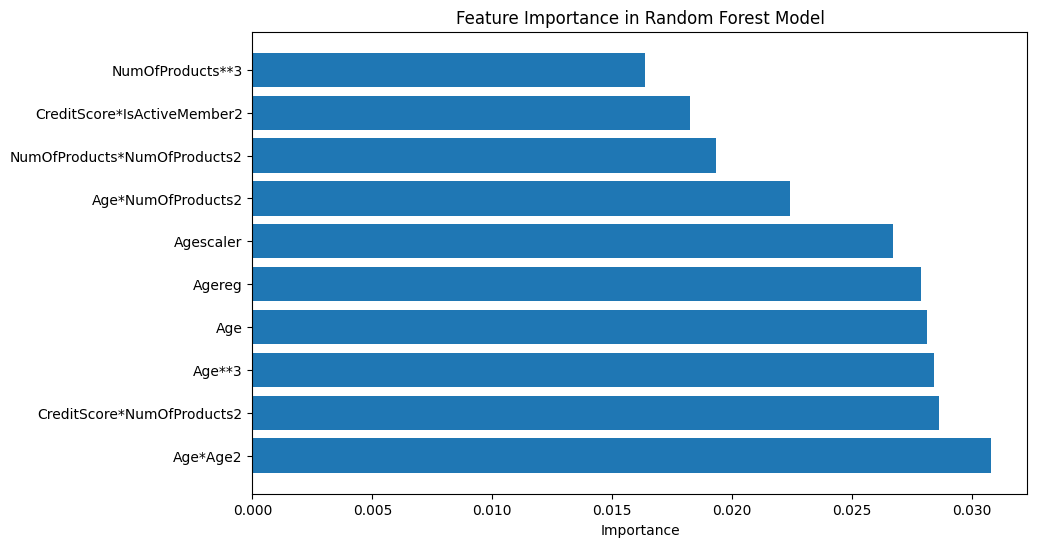

In [448]:
X = train_feture
y = train['Exited']
# Paso 1: Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Paso 2: Crear el modelo Random Forest
rf_model = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],  # Número de árboles en el bosque
    'max_depth': [ 10, 20, 30],  # Profundidad máxima de los árboles
    'min_samples_split': [2, 5, 10],  # Mínimo número de muestras requeridas para dividir un nodo
    'min_samples_leaf': [1, 2, 4, 5],    # Mínimo número de muestras requeridas en una hoja
    'bootstrap': [True],               # Si se deben usar muestras bootstrap para entrenar los árboles
    'max_features': ['auto', 'sqrt'], # Número de características a considerar para la división
    'criterion': ['gini', 'entropy'],        # Criterio para medir la calidad de la división (Gini o Entropía)
    'class_weight': [ 'balanced'],       # Ajuste de pesos para clases desbalanceadas
}
# Paso 4: Configurar GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, 
                           scoring='recall', cv=5, n_jobs=-1, verbose=2)

# Paso 5: Ajustar el modelo utilizando GridSearchCV
grid_search.fit(X_train, y_train)

# Paso 6: Ver los mejores parámetros encontrados
print("Mejores parámetros encontrados: ", grid_search.best_params_)

# Paso 7: Obtener el mejor modelo
rf_model = grid_search.best_estimator_

# Entrenar el modelo
rf_model.fit(X_train, y_train)

# Paso 3: Realizar predicciones
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Mostrar las métricas
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')
print(f'ROC AUC: {roc_auc:.2f}')

# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualizar la matriz de confusión con un gráfico de calor
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Paso 5: Obtener la importancia de las características
importances = rf_model.feature_importances_

# Paso 6: Visualizar la importancia de las características
indices = np.argsort(importances)[::-1]  # Ordenar de mayor a menor

# Paso 5: Visualizar las 10 características más importantes
plt.figure(figsize=(10, 6))
plt.title('Feature Importance in Random Forest Model')

# Gráfico de barras horizontal
plt.barh(range(10), importances[indices[:10]], align='center')

# Establecer las etiquetas de las características más importantes
plt.yticks(range(10), [X.columns[i] for i in indices[:10]])

# Etiquetas y título
plt.xlabel('Importance')
plt.show()

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
720 fits failed out of a total of 1440.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
196 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\ange

Mejores parámetros encontrados:  {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}
Accuracy: 86.69%
Precision: 65.88%
Recall: 60.22%
F1 Score: 62.92%
ROC AUC: 0.77
Confusion Matrix:
[[374  29]
 [ 37  56]]


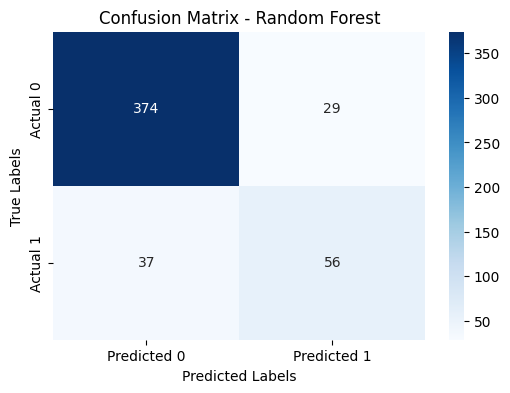

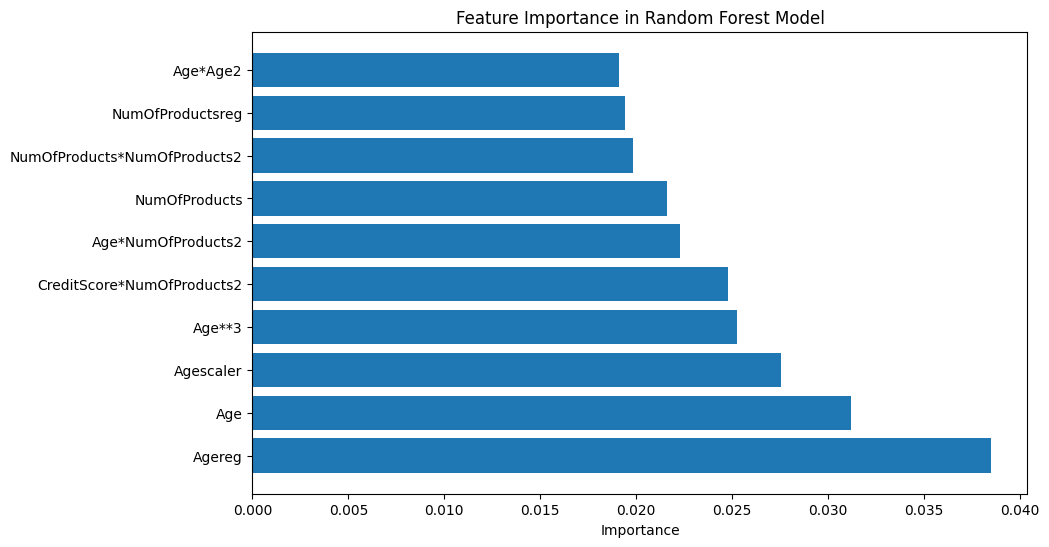

In [453]:
X = train_feture
y = train['Exited']
# Paso 1: Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Paso 2: Crear el modelo Random Forest
rf_model = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100],  # Número de árboles en el bosque
    'max_depth': [ 10, 20, 30],  # Profundidad máxima de los árboles
    'min_samples_split': [2, 5, 10],  # Mínimo número de muestras requeridas para dividir un nodo
    'min_samples_leaf': [1, 2, 4, 5],    # Mínimo número de muestras requeridas en una hoja
    'bootstrap': [True],               # Si se deben usar muestras bootstrap para entrenar los árboles
    'max_features': ['auto', 'sqrt'], # Número de características a considerar para la división
    'criterion': ['gini', 'entropy'],        # Criterio para medir la calidad de la división (Gini o Entropía)
    'class_weight': [ 'balanced'],       # Ajuste de pesos para clases desbalanceadas
}
# Paso 4: Configurar GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, 
                           scoring='recall', cv=5, n_jobs=-1, verbose=2)

# Paso 5: Ajustar el modelo utilizando GridSearchCV
grid_search.fit(X_train, y_train)

# Paso 6: Ver los mejores parámetros encontrados
print("Mejores parámetros encontrados: ", grid_search.best_params_)

# Paso 7: Obtener el mejor modelo
rf_model = grid_search.best_estimator_

# Entrenar el modelo
rf_model.fit(X_train, y_train)

# Paso 3: Realizar predicciones
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Mostrar las métricas
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')
print(f'ROC AUC: {roc_auc:.2f}')

# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualizar la matriz de confusión con un gráfico de calor
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Paso 5: Obtener la importancia de las características
importances = rf_model.feature_importances_

# Paso 6: Visualizar la importancia de las características
indices = np.argsort(importances)[::-1]  # Ordenar de mayor a menor

# Paso 5: Visualizar las 10 características más importantes
plt.figure(figsize=(10, 6))
plt.title('Feature Importance in Random Forest Model')

# Gráfico de barras horizontal
plt.barh(range(10), importances[indices[:10]], align='center')

# Establecer las etiquetas de las características más importantes
plt.yticks(range(10), [X.columns[i] for i in indices[:10]])

# Etiquetas y título
plt.xlabel('Importance')
plt.show()

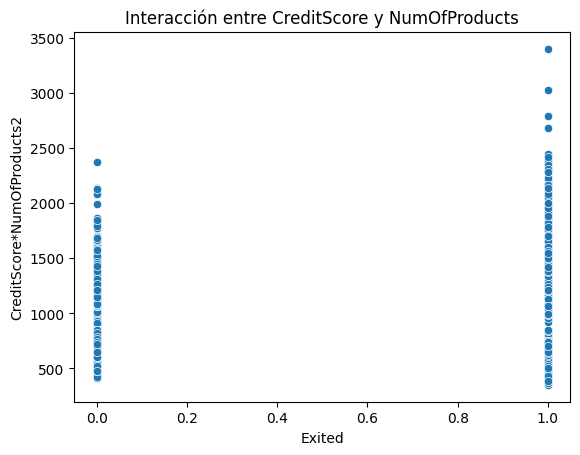

In [467]:
sns.scatterplot(y=train_feture['CreditScore*NumOfProducts2'], x=train_original['Exited'])
plt.title('Interacción entre CreditScore y NumOfProducts')
plt.show()


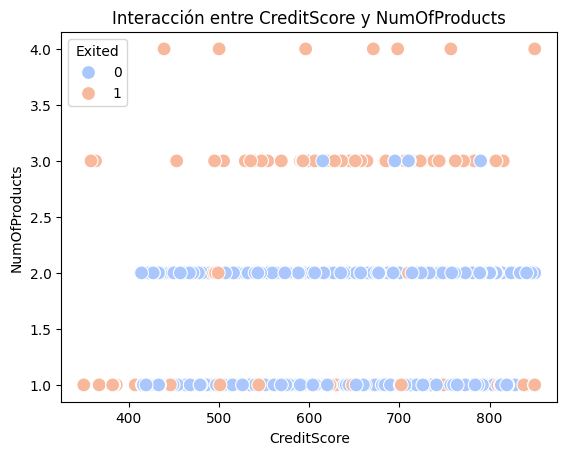

In [468]:
sns.scatterplot(x=X['CreditScore'], y=X['NumOfProducts'], hue=train_original['Exited'], palette="coolwarm", s=100)
plt.title('Interacción entre CreditScore y NumOfProducts')
plt.show()